# Tests de modélisation

Ce notebook regroupe l'ensemble des modélisations réalisées pour prédire la valeur marchande des footballeurs professionnels.

**Contenu :**

Le notebook est organisé en **3 parties** pour garantir des comparaisons équitables :

```
PARTIE A ─── Pipeline commun
              └── Chargement, feature engineering, X/y, fonctions partagées

PARTIE B ─── Expérimentations
              ├── B0 : Modèles baseline
              ├── B1 : Comparaison des algorithmes (cible brute)
              ├── B2 : Comparaison des algorithmes (cible log)
              ├── B3 : Stacking OOF
              ├── B4 : Standardisation de la cible
              ├── B5 : Retrait des valeurs extrêmes
              ├── B6 : Réduction de dimensionnalité
              └── B7 : Modèles séparés Gardiens / Joueurs de champ

PARTIE C ─── Comparaison finale et sélection du modèle champion
              ├── Tableau unique, même test, même pipeline décision
              └── Choix du modèle final
```

## Partie A : Pipeline commun

### A.1 : Imports et configuration

In [112]:
import warnings
warnings.filterwarnings("ignore")
import time

# Manipulation de données
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import sys
import os
import json

# Scikit-Learn
# Imputation et prétraitement
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    MinMaxScaler,
    PowerTransformer,
    QuantileTransformer,
    StandardScaler,
)
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Modèles
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.svm import SVR

# Évaluation et validation
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import cross_val_predict
from sklearn.inspection import permutation_importance

# Modèles de Gradient Boosting
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Optimisation d'hyperparamètres
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.base import clone

# On connecte le notebook à tous les fichiers inclus dans le dossier /fonctions
sys.path.insert(0, os.path.abspath("../fonctions/modelisations"))

%load_ext autoreload
%autoreload 2

# On importe les fonctions utiles à la modélisation
from tests_modelisation import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### A.2 : Chargement des données

Split **temporel** : train 2020-2022 / val 2023 / test 2024. On entraîne toujours sur le passé et on évalue sur le futur.

In [113]:
# Chargement des données

df_train = pd.read_csv("../data_finale/featuring/train_featured.csv")
df_val   = pd.read_csv("../data_finale/featuring/val_featured.csv")
df_test  = pd.read_csv("../data_finale/featuring/test_featured.csv")

### A.3 : Préparation des jeux de données X / y

In [114]:
colonne_cible  = "market_value_in_eur"

data = preparer_donnees(df_train, df_val, df_test, colonne_cible= colonne_cible)

# Extraction de toutes les variables du dictionnaire
X_train = data["X_train"]
y_train = data["y_train"]
y_train_log = data["y_train_log"]
sample_weights_train = data["sample_weights_train"]

X_val = data["X_val"]
y_val = data["y_val"]
y_val_log = data["y_val_log"]

X_test = data["X_test"]
y_test = data["y_test"]
y_test_log = data["y_test_log"]

X_train_sans_nan = data["X_train_sans_nan"]
X_val_sans_nan = data["X_val_sans_nan"]
X_test_sans_nan = data["X_test_sans_nan"]

X_train : (7404, 146) | X_val : (2431, 146) | X_test : (2295, 146)
Filtrage pour les modèles linéaires/SVR :
137 colonnes conservées sur 146.


### A.4 Paramètres d'optimisation d'hyperparamètres

In [115]:
# Nombre d'essais pour l'optimisation d'hyperparamètres et graine aléatoire

N_TRIALS     = 75
RANDOM_STATE = 1308

# On crée des copies des données pour les tests finaux réalisés en partie C

X_test_final, y_test_final, df_test_final = X_test.copy(), y_test.copy(), df_test.copy()
X_test_sans_nan_final =  X_test_sans_nan.copy()

## Partie B : Expérimentations

> Toutes les parties utilisent **exactement** les mêmes `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test` issus de la partie A.

### B0 : Modèles baseline

On définit 5 modèles sans tuning : Random Forest, Extra Trees, XGBoost, LightGBM et CatBoost, avec des hyperparamètres fixes. L'objectif est d'établir une référence rapide avant toute optimisation.

#### B0.1 : Définition des modèles

In [116]:
modeles = {
    # Forêts
    "Random Forest": RandomForestRegressor(
        random_state=1308, n_jobs=-1, n_estimators=100
    ),
    "Extra Trees": ExtraTreesRegressor(
        random_state=1308, n_jobs=-1, n_estimators=100
    ),
    # Boosting
    "XGBoost": XGBRegressor(
        random_state=1308, n_jobs=-1, n_estimators=100, learning_rate=0.1
    ),
    "LightGBM": LGBMRegressor(
        random_state=1308, n_jobs=-1, n_estimators=100, learning_rate=0.1, verbose=-1
    ),
    "CatBoost": CatBoostRegressor(
        random_state=1308, iterations=100, learning_rate=0.1, verbose=0
    ),
}

#### B0.2 : Évaluation sur la validation

Évaluation de chaque modèle sur le jeu de validation. Les métriques calculées sont : MAE, RMSE, MAPE, R² et R² ajusté.

In [117]:
# Évaluation sur la validation

df_res_val, res_val_dict = evaluer_modeles(modeles, data, mode="val")

Entraînement de Random Forest...
   -> Validation | MAE : 3,542,450 € | RMSE : 6,766,621 € | MAPE : 70.38% | R² : 85.86% | R² Ajusté : 84.96%
Entraînement de Extra Trees...
   -> Validation | MAE : 3,332,044 € | RMSE : 6,303,096 € | MAPE : 69.06% | R² : 87.73% | R² Ajusté : 86.95%
Entraînement de XGBoost...
   -> Validation | MAE : 3,273,348 € | RMSE : 5,896,817 € | MAPE : 71.34% | R² : 89.26% | R² Ajusté : 88.58%
Entraînement de LightGBM...
   -> Validation | MAE : 3,252,614 € | RMSE : 6,065,886 € | MAPE : 71.65% | R² : 88.64% | R² Ajusté : 87.91%
Entraînement de CatBoost...
   -> Validation | MAE : 3,393,157 € | RMSE : 6,261,310 € | MAPE : 82.01% | R² : 87.90% | R² Ajusté : 87.12%

Classement final Validation (trié par MAE croissante)
       Modèle Erreur moyenne Validation (MAE) Score R² Validation Score R² Ajusté Validation
     LightGBM                     3,252,614 €              88.64%                     87.91%
      XGBoost                     3,273,348 €              89.26%  

#### B0.3 : Évaluation sur le test

Le test est évalué **une seule fois**, uniquement pour avoir une référence de la performance réelle avant tuning.

In [118]:
# Évaluation sur le test

df_res_test, res_test_dict = evaluer_modeles(modeles, data, mode="test")

Entraînement de Random Forest...
   -> Test | MAE : 3,765,331 € | RMSE : 7,247,051 € | MAPE : 66.03% | R² : 84.95% | R² Ajusté : 83.93%
Entraînement de Extra Trees...
   -> Test | MAE : 3,482,186 € | RMSE : 6,654,815 € | MAPE : 60.74% | R² : 87.31% | R² Ajusté : 86.45%
Entraînement de XGBoost...
   -> Test | MAE : 3,424,375 € | RMSE : 6,164,642 € | MAPE : 62.96% | R² : 89.11% | R² Ajusté : 88.37%
Entraînement de LightGBM...
   -> Test | MAE : 3,571,105 € | RMSE : 7,047,720 € | MAPE : 67.06% | R² : 85.77% | R² Ajusté : 84.80%
Entraînement de CatBoost...
   -> Test | MAE : 3,579,644 € | RMSE : 6,827,094 € | MAPE : 69.65% | R² : 86.64% | R² Ajusté : 85.74%

Classement final Test (trié par MAE croissante)
       Modèle Erreur moyenne Test (MAE) Score R² Test Score R² Ajusté Test
      XGBoost               3,424,375 €        89.11%               88.37%
  Extra Trees               3,482,186 €        87.31%               86.45%
     LightGBM               3,571,105 €        85.77%           

### B1 : Comparaison des algorithmes (cible brute)

**Ce qu'on teste :** quel algorithme, tuné avec Optuna, donne les meilleures performances ?

**Modèles comparés :** Random Forest, Extra Trees, XGBoost, LightGBM, CatBoost, SVR et ElasticNet.

**Objectif Optuna :** RMSE.

**Ce qui varie ici :** l'algorithme.  
**Ce qui reste fixe :** pipeline Bloc A, objectif RMSE log, `N_TRIALS = 75`, `sample_weight = 1/log1p(y)`.

#### B1.1 : Tuning Random Forest et Extra Trees

In [119]:
study_rf = optuna.create_study( direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE) )

study_rf.optimize(
    lambda t: tune_forest(RandomForestRegressor, t, random_state=RANDOM_STATE,
                          X_train=X_train, y_train=y_train, y_train_log=y_train_log, X_val=X_val, y_val=y_val),
    n_trials=N_TRIALS,
    show_progress_bar=True
)
print("Meilleur RMSE :", study_rf.best_value)
print("Meilleurs paramètres :", study_rf.best_params)

  0%|          | 0/75 [00:00<?, ?it/s]

Best trial: 47. Best value: 6.5787e+06: 100%|██████████| 75/75 [16:54<00:00, 13.52s/it] 

Meilleur RMSE : 6578701.057754778
Meilleurs paramètres : {'n_estimators': 500, 'max_depth': 40, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 1.0}


In [120]:
study_et = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))

study_et.optimize(
    lambda t: tune_forest(ExtraTreesRegressor, t, random_state=RANDOM_STATE,
                          X_train=X_train, y_train=y_train, y_train_log=y_train_log, X_val=X_val, y_val=y_val),
    n_trials=N_TRIALS,
    show_progress_bar=True
)
print("Meilleur RMSE :", study_et.best_value)
print("Meilleurs paramètres :", study_et.best_params)

Best trial: 49. Best value: 6.14794e+06: 100%|██████████| 75/75 [13:35<00:00, 10.87s/it]

Meilleur RMSE : 6147940.346569158
Meilleurs paramètres : {'n_estimators': 600, 'max_depth': 23, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 1.0}


#### B1.2 : Tuning XGBoost

In [121]:
study_xgb = optuna.create_study( direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))

study_xgb.optimize(
    lambda t: tune_xgb(XGBRegressor, t, random_state=RANDOM_STATE,
                        X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val,
    ),
    n_trials=N_TRIALS,
    show_progress_bar=True,
)
print("Meilleur RMSE :", study_xgb.best_value)
print("Meilleurs paramètres :", study_xgb.best_params)

Best trial: 48. Best value: 5.56465e+06: 100%|██████████| 75/75 [28:30<00:00, 22.81s/it]

Meilleur RMSE : 5564651.053487312
Meilleurs paramètres : {'n_estimators': 5000, 'max_depth': 5, 'learning_rate': 0.021701788799246384, 'subsample': 0.8096671784565523, 'colsample_bytree': 0.8680294439308445, 'min_child_weight': 3.9580236589936035, 'reg_alpha': 0.0004751383609344289, 'reg_lambda': 0.0034070672847021292}


#### B1.3 : Tuning LightGBM

In [122]:
study_lgbm = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)

study_lgbm.optimize(
    lambda t: tune_lgbm(LGBMRegressor, t, random_state=RANDOM_STATE,
                       X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val),
    n_trials=N_TRIALS,
    show_progress_bar=True,
)
print("Meilleur RMSE :", study_lgbm.best_value)
print("Meilleurs paramètres :", study_lgbm.best_params)

Best trial: 22. Best value: 5.76774e+06: 100%|██████████| 75/75 [06:51<00:00,  5.48s/it]

Meilleur RMSE : 5767738.819782222
Meilleurs paramètres : {'n_estimators': 3250, 'num_leaves': 223, 'max_depth': 4, 'learning_rate': 0.01580043292030045, 'subsample': 0.9905475219427162, 'colsample_bytree': 0.8002190799438189, 'reg_alpha': 0.29193019450541235, 'reg_lambda': 0.0041327670371515066}


#### B1.4 : Tuning CatBoost

In [123]:
study_cat = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_cat.optimize(
    lambda t: tune_catboost(CatBoostRegressor, t, random_state=RANDOM_STATE,
                            X_train=X_train, y_train=y_train,
                            X_val=X_val, y_val=y_val),
    n_trials=N_TRIALS,
    show_progress_bar=True,
)
print("Meilleur RMSE :", study_cat.best_value)
print("Meilleurs paramètres :", study_cat.best_params)

Best trial: 59. Best value: 5.62799e+06: 100%|██████████| 75/75 [14:11<00:00, 11.35s/it]

Meilleur RMSE : 5627993.084761335
Meilleurs paramètres : {'learning_rate': 0.028249111642360963, 'iterations': 3000, 'depth': 5, 'l2_leaf_reg': 1.8357793428074818, 'subsample': 0.7346052596452911}


#### B1.5 : Tuning SVR & ElasticNet

SVR et ElasticNet nécessitent une standardisation préalable et ne tolèrent pas les NaN.
On travaille sur un sous-ensemble de colonnes sans valeurs manquantes.

In [124]:
study_svr = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)

study_svr.optimize(
    lambda t: tune_svr(t, X_train_sans_nan=X_train_sans_nan,
                       y_train=y_train, X_val_sans_nan=X_val_sans_nan, y_val=y_val, ),
    n_trials=N_TRIALS,
    show_progress_bar=True,
)

print("Meilleur RMSE :", study_svr.best_value)
print("Meilleurs paramètres :", study_svr.best_params)

Best trial: 68. Best value: 1.75794e+07: 100%|██████████| 75/75 [09:06<00:00,  7.29s/it]

Meilleur RMSE : 17579418.683374062
Meilleurs paramètres : {'C': 99.76215625711077, 'epsilon': 0.023051902254883485, 'kernel': 'linear', 'gamma': 'auto'}


In [125]:
study_enet = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)

study_enet.optimize(
    lambda t: tune_enet( t, use_log=False, random_state=RANDOM_STATE,X_train_sans_nan=X_train_sans_nan,
                        y_train=y_train, y_train_log=y_train_log, X_val_sans_nan=X_val_sans_nan, y_val=y_val,
    ),
    n_trials=N_TRIALS,
    show_progress_bar=True,
)
print("Meilleur RMSE :", study_enet.best_value)
print("Meilleurs paramètres :", study_enet.best_params)

Best trial: 15. Best value: 1.02937e+07: 100%|██████████| 75/75 [05:29<00:00,  4.39s/it]

Meilleur RMSE : 10293660.239174405
Meilleurs paramètres : {'alpha': 0.0054393919223239455, 'l1_ratio': 0.43823612147836244}


#### B1.6 : Construction des modèles finaux

In [126]:
modeles_tuned = {
    "Random Forest": RandomForestRegressor(**study_rf.best_params, random_state=RANDOM_STATE, n_jobs=-1),
    "Extra Trees":   ExtraTreesRegressor(**study_et.best_params, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost":       XGBRegressor(**study_xgb.best_params, tree_method="hist", enable_categorical=True,
                                   objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    "LightGBM":      LGBMRegressor(**study_lgbm.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    "CatBoost":      CatBoostRegressor(**study_cat.best_params, bootstrap_type="Bernoulli",
                                        random_state=RANDOM_STATE, early_stopping_rounds=100, verbose=0),
}

modeles_tuned_sans_nan = {
    "SVR":        Pipeline([("scaler", StandardScaler()), ("svr", SVR(**study_svr.best_params))]),
    "ElasticNet": Pipeline([("scaler", StandardScaler()),
                             ("enet", ElasticNet(**study_enet.best_params, random_state=RANDOM_STATE, max_iter=10000))]),
}

#### B1.7 : Évaluation sur la validation

On évalue chaque modèle tuné sur la validation pour comparer et choisir le meilleur avant de toucher au test.

In [127]:
evaluer_modeles_tuned( modeles_tuned, modeles_tuned_sans_nan, data=data, mode="val", use_log=False, )

Entraînement (tuné) de Random Forest...
Entraînement (tuné) de Extra Trees...
Entraînement (tuné) de XGBoost...
Entraînement (tuné) de LightGBM...
Entraînement (tuné) de CatBoost...
Entraînement (tuné) de SVR...
Entraînement (tuné) de ElasticNet...

Classement (Validation, modèles tunés)
                        MAE          RMSE      MAPE        R2  R2 Ajusté
CatBoost       3.110086e+06  5.611140e+06  0.726963  0.902791   0.896578
XGBoost        3.200813e+06  5.564651e+06  0.752567  0.904395   0.898284
Extra Trees    3.218869e+06  6.147940e+06  0.668149  0.883302   0.875843
LightGBM       3.298558e+06  5.767739e+06  0.783455  0.897290   0.890724
Random Forest  3.441588e+06  6.578701e+06  0.696775  0.866377   0.857835
ElasticNet     6.296372e+06  1.029366e+07  2.820516  0.672854   0.653308
SVR            8.310186e+06  1.757942e+07  1.099345  0.045861  -0.011146


,MAE,RMSE,MAPE,R2,R2 Ajusté
CatBoost,3.110086e+06,5.611140e+06,0.726963,0.902791,0.896578
XGBoost,3.200813e+06,5.564651e+06,0.752567,0.904395,0.898284
Extra Trees,3.218869e+06,6.147940e+06,0.668149,0.883302,0.875843
LightGBM,3.298558e+06,5.767739e+06,0.783455,0.897290,0.890724
Random Forest,3.441588e+06,6.578701e+06,0.696775,0.866377,0.857835
ElasticNet,6.296372e+06,1.029366e+07,2.820516,0.672854,0.653308
SVR,8.310186e+06,1.757942e+07,1.099345,0.045861,-0.011146


#### B1.8 : Évaluation finale sur le test

In [128]:
evaluer_modeles_tuned( modeles_tuned, modeles_tuned_sans_nan, data=data, mode="test", use_log=False, )

Entraînement (tuné) de Random Forest...
Entraînement (tuné) de Extra Trees...
Entraînement (tuné) de XGBoost...
Entraînement (tuné) de LightGBM...
Entraînement (tuné) de CatBoost...
Entraînement (tuné) de SVR...
Entraînement (tuné) de ElasticNet...

Classement (Test, modèles tunés)
                        MAE          RMSE      MAPE        R2  R2 Ajusté
CatBoost       3.350517e+06  6.205896e+06  0.653315  0.889646   0.882146
XGBoost        3.388841e+06  5.809673e+06  0.708193  0.903288   0.896714
Extra Trees    3.395808e+06  6.536517e+06  0.596042  0.877575   0.869254
LightGBM       3.628135e+06  6.701045e+06  0.666049  0.871334   0.862589
Random Forest  3.707002e+06  7.199463e+06  0.637409  0.851482   0.841388
ElasticNet     6.774994e+06  1.120320e+07  2.494537  0.640365   0.617523
SVR            9.021504e+06  1.853839e+07  1.104533  0.015259  -0.047286


,MAE,RMSE,MAPE,R2,R2 Ajusté
CatBoost,3.350517e+06,6.205896e+06,0.653315,0.889646,0.882146
XGBoost,3.388841e+06,5.809673e+06,0.708193,0.903288,0.896714
Extra Trees,3.395808e+06,6.536517e+06,0.596042,0.877575,0.869254
LightGBM,3.628135e+06,6.701045e+06,0.666049,0.871334,0.862589
Random Forest,3.707002e+06,7.199463e+06,0.637409,0.851482,0.841388
ElasticNet,6.774994e+06,1.120320e+07,2.494537,0.640365,0.617523
SVR,9.021504e+06,1.853839e+07,1.104533,0.015259,-0.047286


### B2 : Comparaison des algorithmes (cible log)

**Ce qu'on teste :** quel algorithme, tuné avec Optuna, donne les meilleures performances ?

**Modèles comparés :** Random Forest, Extra Trees, XGBoost, LightGBM, CatBoost, SVR et ElasticNet.

**Objectif Optuna :** RMSE log. On entraîne sur `log1p(y)` et on retransforme avec `expm1` pour les métriques.

**Ce qui varie ici :** l'algorithme.  
**Ce qui reste fixe :** pipeline Bloc A, objectif RMSE log, `N_TRIALS = 75`, `sample_weight = 1/log1p(y)`.

#### B2.1 : Tuning Random Forest & Extra Trees

In [129]:
study_rf_log = optuna.create_study( direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE) )

study_rf_log.optimize(
    lambda t: tune_forest(RandomForestRegressor, t, use_log=True, random_state=RANDOM_STATE,
                          X_train=X_train, y_train=y_train, y_train_log=y_train_log, X_val=X_val, y_val=y_val),
    n_trials=N_TRIALS,
    show_progress_bar=True
)
print("Meilleur RMSE :", study_rf_log.best_value)
print("Meilleurs paramètres :", study_rf_log.best_params)

Best trial: 70. Best value: 6.99165e+06: 100%|██████████| 75/75 [13:00<00:00, 10.41s/it]

Meilleur RMSE : 6991645.497061528
Meilleurs paramètres : {'n_estimators': 900, 'max_depth': 29, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 0.8}


In [130]:
study_et_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))

study_et_log.optimize(
    lambda t: tune_forest(ExtraTreesRegressor, t, use_log=True, random_state=RANDOM_STATE,
                          X_train=X_train, y_train=y_train, y_train_log=y_train_log, X_val=X_val, y_val=y_val),
    n_trials=N_TRIALS,
    show_progress_bar=True
)
print("Meilleur RMSE :", study_et_log.best_value)
print("Meilleurs paramètres :", study_et_log.best_params)

Best trial: 73. Best value: 6.76541e+06: 100%|██████████| 75/75 [16:42<00:00, 13.37s/it]

Meilleur RMSE : 6765409.781645047
Meilleurs paramètres : {'n_estimators': 900, 'max_depth': 21, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 1.0}


#### B2.3 : Tuning XGBoost

In [131]:
study_xgb_log = optuna.create_study( direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))

study_xgb_log.optimize(
    lambda t: tune_xgb(XGBRegressor, t, transfo={"transform": np.log1p, "inverse": np.expm1}, random_state=RANDOM_STATE,
                        X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val,
    ),
    n_trials=N_TRIALS,
    show_progress_bar=True,
)
print("Meilleur RMSE :", study_xgb_log.best_value)
print("Meilleurs paramètres :", study_xgb_log.best_params)

Best trial: 21. Best value: 5.5614e+06: 100%|██████████| 75/75 [33:18<00:00, 26.64s/it] 

Meilleur RMSE : 5561402.291949836
Meilleurs paramètres : {'n_estimators': 5000, 'max_depth': 6, 'learning_rate': 0.008908567949954786, 'subsample': 0.7856609068824933, 'colsample_bytree': 0.8110887201007839, 'min_child_weight': 1.4375522611067058, 'reg_alpha': 0.003908994088630441, 'reg_lambda': 0.06680616267702491}


#### B2.4 : Tuning LightGBM

In [132]:
study_lgbm_log = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)

study_lgbm_log.optimize(
    lambda t: tune_lgbm(LGBMRegressor, t, transfo={"transform": np.log1p, "inverse": np.expm1}, random_state=RANDOM_STATE,
                       X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val),
    n_trials=N_TRIALS,
    show_progress_bar=True,
)
print("Meilleur RMSE :", study_lgbm_log.best_value)
print("Meilleurs paramètres :", study_lgbm_log.best_params)

Best trial: 44. Best value: 5.77978e+06: 100%|██████████| 75/75 [16:50<00:00, 13.48s/it]

Meilleur RMSE : 5779781.749028069
Meilleurs paramètres : {'n_estimators': 2750, 'num_leaves': 196, 'max_depth': 7, 'learning_rate': 0.006557988447773862, 'subsample': 0.9593966827636948, 'colsample_bytree': 0.7404367434799205, 'reg_alpha': 0.1538550546668315, 'reg_lambda': 0.004730511374207176}


#### B2.5 : Tuning CatBoost

In [133]:
study_cat_log = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_cat_log.optimize(
    lambda t: tune_catboost(CatBoostRegressor, t, transfo={"transform": np.log1p, "inverse": np.expm1}, random_state=RANDOM_STATE,
                            X_train=X_train, y_train=y_train,
                            X_val=X_val, y_val=y_val),
    n_trials=N_TRIALS,
    show_progress_bar=True,
)
print("Meilleur RMSE :", study_cat_log.best_value)
print("Meilleurs paramètres :", study_cat_log.best_params)

Best trial: 23. Best value: 5.94397e+06: 100%|██████████| 75/75 [1:05:10<00:00, 52.14s/it]

Meilleur RMSE : 5943972.454026171
Meilleurs paramètres : {'learning_rate': 0.023320965394393704, 'iterations': 7000, 'depth': 6, 'l2_leaf_reg': 5.587329906441078, 'subsample': 0.993817408333189}


#### B2.6 : Tuning SVR & ElasticNet

SVR et ElasticNet nécessitent une standardisation préalable et ne tolèrent pas les NaN.
On travaille sur un sous-ensemble de colonnes sans valeurs manquantes.

In [134]:
study_svr_log = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)

study_svr_log.optimize(
    lambda t: tune_svr(t, use_log=True, X_train_sans_nan=X_train_sans_nan, y_train=y_train,
                       y_train_log=y_train_log, X_val_sans_nan=X_val_sans_nan, y_val=y_val, ),
    n_trials=N_TRIALS,
    show_progress_bar=True,
)

print("Meilleur RMSE :", study_svr_log.best_value)
print("Meilleurs paramètres :", study_svr_log.best_params)

Best trial: 68. Best value: 8.77912e+06: 100%|██████████| 75/75 [47:44<00:00, 38.20s/it]   

Meilleur RMSE : 8779124.111906603
Meilleurs paramètres : {'C': 1.4230996080275287, 'epsilon': 0.07134386498798163, 'kernel': 'rbf', 'gamma': 'auto'}


In [135]:
study_enet_log = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)

study_enet_log.optimize(
    lambda t: tune_enet(t, use_log=True, random_state=RANDOM_STATE, X_train_sans_nan=X_train_sans_nan,
                        y_train=y_train, y_train_log=y_train_log, X_val_sans_nan=X_val_sans_nan, y_val=y_val),
    n_trials=N_TRIALS,
    show_progress_bar=True,
)
print("Meilleur RMSE :", study_enet_log.best_value)
print("Meilleurs paramètres :", study_enet_log.best_params)

Best trial: 49. Best value: 9.13698e+06: 100%|██████████| 75/75 [00:39<00:00,  1.90it/s]

Meilleur RMSE : 9136979.148538899
Meilleurs paramètres : {'alpha': 0.09801877043587172, 'l1_ratio': 0.6475143867855085}


#### B2.7 — Construction des modèles finaux

In [136]:
modeles_tuned_log = {
    "Random Forest (log)": RandomForestRegressor(**study_rf_log.best_params, random_state=RANDOM_STATE, n_jobs=-1),
    "Extra Trees (log)":   ExtraTreesRegressor(**study_et_log.best_params, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost (log)":       XGBRegressor(**study_xgb_log.best_params, tree_method="hist", enable_categorical=True,
                                          objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    "LightGBM (log)":      LGBMRegressor(**study_lgbm_log.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    "CatBoost (log)":      CatBoostRegressor(**study_cat_log.best_params, bootstrap_type="Bernoulli",
                                               random_state=RANDOM_STATE, verbose=0),
}

modeles_tuned_log_sans_nan = {
    "SVR (log)":        Pipeline([("scaler", StandardScaler()), ("svr", SVR(**study_svr_log.best_params))]),
    "ElasticNet (log)": Pipeline([("scaler", StandardScaler()),
                                   ("enet", ElasticNet(**study_enet_log.best_params, random_state=RANDOM_STATE, max_iter=10000))]),
}

In [137]:
# Regroupement de tous les meilleurs paramètres dans un seul dictionnaire
meilleurs_params = {
    "Random Forest": study_rf_log.best_params,
    "Extra Trees": study_et_log.best_params,
    "XGBoost": study_xgb_log.best_params,
    "LightGBM": study_lgbm_log.best_params,
    "CatBoost": study_cat_log.best_params,
    "SVR": study_svr_log.best_params,
    "ElasticNet": study_enet_log.best_params,
}

# Sauvegarde dans un fichier JSON
with open("../modelisation/meilleurs_hyperparametres.json", "w") as f:
    json.dump(meilleurs_params, f, indent=4)

#### B2.8 : Évaluation et comparaison avec/sans transformation

La fonction `evaluer_log` entraîne sur `log1p(y)`, retransforme les prédictions avec `expm1`, puis calcule toutes les métriques en euros, ce qui rend les deux approches directement comparables.

In [138]:
evaluer_modeles_tuned( modeles_tuned_log, modeles_tuned_log_sans_nan, data=data, mode="val", use_log=True, )

Entraînement (tuné) de Random Forest (log)...
Entraînement (tuné) de Extra Trees (log)...
Entraînement (tuné) de XGBoost (log)...
Entraînement (tuné) de LightGBM (log)...
Entraînement (tuné) de CatBoost (log)...
Entraînement (tuné) de SVR (log)...
Entraînement (tuné) de ElasticNet (log)...

Classement (Validation, modèles tunés)
                              MAE          RMSE      MAPE        R2  R2 Ajusté
XGBoost (log)        2.969219e+06  5.561402e+06  0.431091  0.904507   0.898403
LightGBM (log)       2.985729e+06  5.779782e+06  0.427001  0.896860   0.890267
CatBoost (log)       3.106346e+06  5.956021e+06  0.436738  0.890475   0.883473
Extra Trees (log)    3.326488e+06  6.765410e+06  0.455402  0.858684   0.849651
Random Forest (log)  3.413212e+06  6.991645e+06  0.459807  0.849075   0.839427
SVR (log)            4.286796e+06  8.779124e+06  0.629405  0.762040   0.747822
ElasticNet (log)     4.530194e+06  9.136979e+06  0.654919  0.742245   0.726844


,MAE,RMSE,MAPE,R2,R2 Ajusté
XGBoost (log),2.969219e+06,5.561402e+06,0.431091,0.904507,0.898403
LightGBM (log),2.985729e+06,5.779782e+06,0.427001,0.896860,0.890267
CatBoost (log),3.106346e+06,5.956021e+06,0.436738,0.890475,0.883473
Extra Trees (log),3.326488e+06,6.765410e+06,0.455402,0.858684,0.849651
Random Forest (log),3.413212e+06,6.991645e+06,0.459807,0.849075,0.839427
SVR (log),4.286796e+06,8.779124e+06,0.629405,0.762040,0.747822
ElasticNet (log),4.530194e+06,9.136979e+06,0.654919,0.742245,0.726844


#### B2.9 — Évaluation finale sur le test

In [139]:
evaluer_modeles_tuned( modeles_tuned_log, modeles_tuned_log_sans_nan, data=data, mode="test", use_log=True, )

Entraînement (tuné) de Random Forest (log)...
Entraînement (tuné) de Extra Trees (log)...
Entraînement (tuné) de XGBoost (log)...
Entraînement (tuné) de LightGBM (log)...
Entraînement (tuné) de CatBoost (log)...
Entraînement (tuné) de SVR (log)...
Entraînement (tuné) de ElasticNet (log)...

Classement (Test, modèles tunés)
                              MAE          RMSE      MAPE        R2  R2 Ajusté
XGBoost (log)        3.232319e+06  6.243502e+06  0.410089  0.888305   0.880713
LightGBM (log)       3.304643e+06  6.589856e+06  0.405331  0.875569   0.867111
CatBoost (log)       3.427334e+06  6.503515e+06  0.415181  0.878808   0.870570
Extra Trees (log)    3.505576e+06  7.395040e+06  0.419090  0.843304   0.832653
Random Forest (log)  3.660397e+06  7.830031e+06  0.431814  0.824327   0.812387
SVR (log)            4.606889e+06  1.009009e+07  0.573077  0.708279   0.689750
ElasticNet (log)     4.651563e+06  9.158104e+06  0.643683  0.759680   0.744417


,MAE,RMSE,MAPE,R2,R2 Ajusté
XGBoost (log),3.232319e+06,6.243502e+06,0.410089,0.888305,0.880713
LightGBM (log),3.304643e+06,6.589856e+06,0.405331,0.875569,0.867111
CatBoost (log),3.427334e+06,6.503515e+06,0.415181,0.878808,0.870570
Extra Trees (log),3.505576e+06,7.395040e+06,0.419090,0.843304,0.832653
Random Forest (log),3.660397e+06,7.830031e+06,0.431814,0.824327,0.812387
SVR (log),4.606889e+06,1.009009e+07,0.573077,0.708279,0.689750
ElasticNet (log),4.651563e+06,9.158104e+06,0.643683,0.759680,0.744417


### B3 : Stacking OOF (XGBoost + LightGBM + CatBoost)

Le Stacking OOF combine les 3 meilleurs modèles boosting via un méta-modèle linéaire à coefficients positifs (combinaison convexe).

Les prédictions OOF garantissent que chaque exemple du train reçoit une prédiction issue d'un modèle qui ne l'a jamais vu, contrairement à un split fixe qui biaiserait les poids du méta-modèle.

#### B3.1 — Génération des prédictions OOF et construction du méta-modèle

In [140]:
base_models_log = ["CatBoost (log)", "XGBoost (log)", "LightGBM (log)"]

# Génération des méta-features
X_meta_train, X_meta_val, X_meta_test, temps_fit = preparer_meta_features(
    base_models_names=base_models_log, modeles_dict=modeles_tuned_log, data=data
)

Génération des OOF predictions (cross_val_predict, cv=5)...
  CatBoost (log) : OOF RMSE = 6,008,703 € (278.3s)
  XGBoost (log) : OOF RMSE = 6,054,821 € (104.1s)
  LightGBM (log) : OOF RMSE = 6,141,340 € (52.8s)


#### B3.2 — Comparaison Blend (moyenne) vs Stacking OOF

On compare deux stratégies d'assemblage :
- **Blend (moyenne simple)** : moyenne arithmétique des 3 prédictions : rapide mais sous-optimal
- **Stacking OOF** : méta-modèle linéaire à coefficients positifs : apprend les poids optimaux

In [141]:
# Évaluation des ensembles et récupération des prédictions

pred_val_moyenne, pred_test_moyenne, pred_val_stack, pred_test_stack, meta_modele, comparaison_blend = evaluer_ensembles(
    X_meta_train, X_meta_val, X_meta_test, data=data, modeles_tuned_log=modeles_tuned_log,
    nom_modele_seul="CatBoost (log)", )

Blend (moyenne simple)
  Val  -> MAE : 2,925,644 € | R² : 0.9050
  Test -> MAE : 3,224,552 € | R² : 0.8886

Poids appris par le méta-modèle : {'CatBoost (log)': np.float64(0.486), 'XGBoost (log)': np.float64(0.189), 'LightGBM (log)': np.float64(0.382)}
Intercept : 363,807 €

Stacking OOF (méta-modèle)
  Val  -> MAE : 2,973,504 € | R² : 0.9061
  Test -> MAE : 3,319,620 € | R² : 0.8925

                           MAE Val    R2 Val      MAE Test   R2 Test
Blend (moyenne)       2.925644e+06  0.904979  3.224552e+06  0.888555
Blend (stacking OOF)  2.973504e+06  0.906117  3.319620e+06  0.892517
CatBoost (log) seul   3.106346e+06  0.890475  3.427334e+06  0.878808


In [142]:
# Extraction des paramètres appris par la régression linéaire
meta_config = { "weights": dict(zip(base_models_log, meta_modele.coef_.tolist())),
    "intercept": float(meta_modele.intercept_) }

with open("../modelisation/poids_stacking.json", "w") as f:
    json.dump(meta_config, f, indent=4)

In [143]:
df_comparaison = comparaison_des_blend(data=data, modeles_tuned_log=modeles_tuned_log,
                                       pred_val_moyenne=pred_val_moyenne, pred_test_moyenne=pred_test_moyenne,
                                       pred_val_stack=pred_val_stack, pred_test_stack=pred_test_stack,
                                       nom_modele_seul="CatBoost (log)", )

                           MAE Val    R2 Val      MAE Test   R2 Test
Blend (moyenne)       2.925644e+06  0.904979  3.224552e+06  0.888555
Blend (stacking OOF)  2.973504e+06  0.906117  3.319620e+06  0.892517
CatBoost (log) seul   3.106346e+06  0.890475  3.427334e+06  0.878808


#### B3.3 — Analyse d'erreur par tranche de valeur

On décompose l'erreur du meilleur modèle par tranche de valeur marchande pour identifier où le modèle peine le plus.

         n_joueurs  valeur_moyenne           MAE      MAPE  \
tranche                                                      
<5M€          1075    2.417744e+06  1.081967e+06  0.804768   
5-20M€         795    1.164088e+07  3.478147e+06  0.312001   
20-50M€        343    3.234111e+07  6.721833e+06  0.212999   
>50M€           82    8.414634e+07  1.688656e+07  0.197552   

         % du total joueurs  % de l'erreur absolue totale  
tranche                                                    
<5M€              46.840959                     15.266917  
5-20M€            34.640523                     36.294761  
20-50M€           14.945534                     30.262918  
>50M€              3.572985                     18.175404  


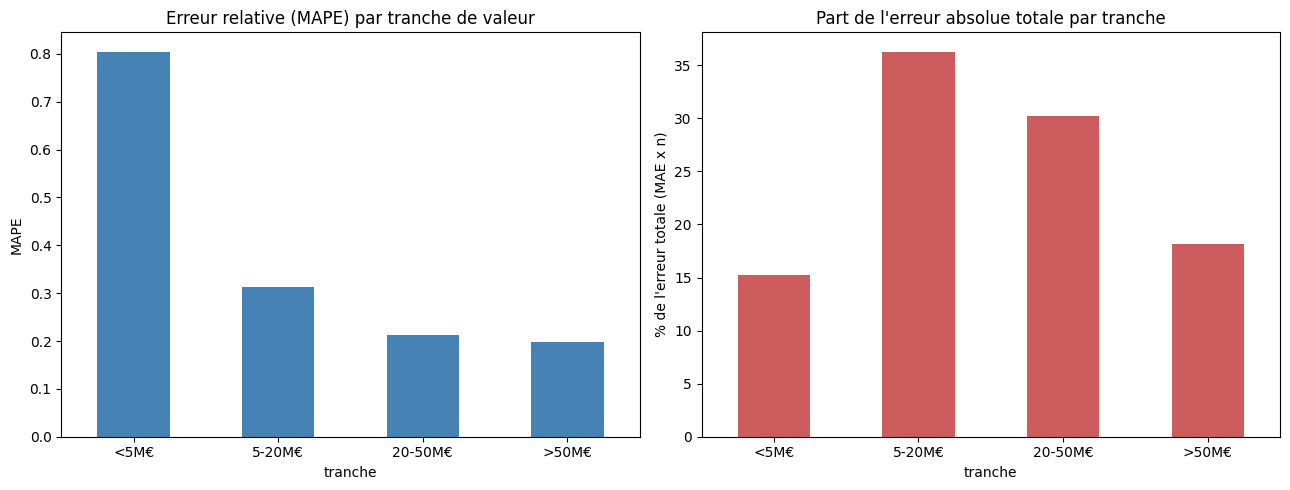

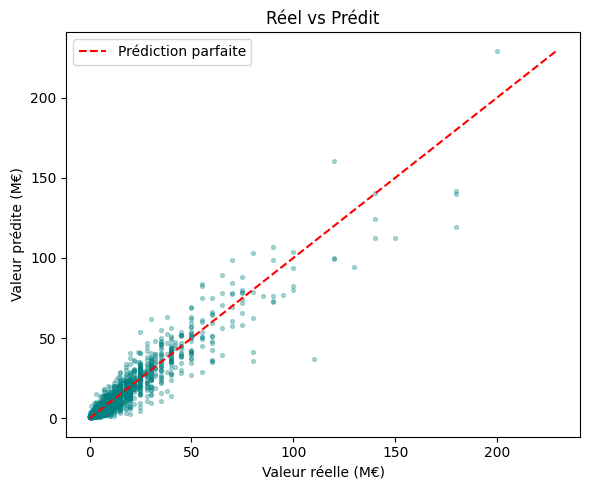

In [144]:
synthese_tranches = analyser_erreurs_par_tranches(y_test=data["y_test"], meilleure_prediction_test=pred_test_stack,
                                                  random_state=RANDOM_STATE)

#### B3.4 — Feature importance (XGBoost)

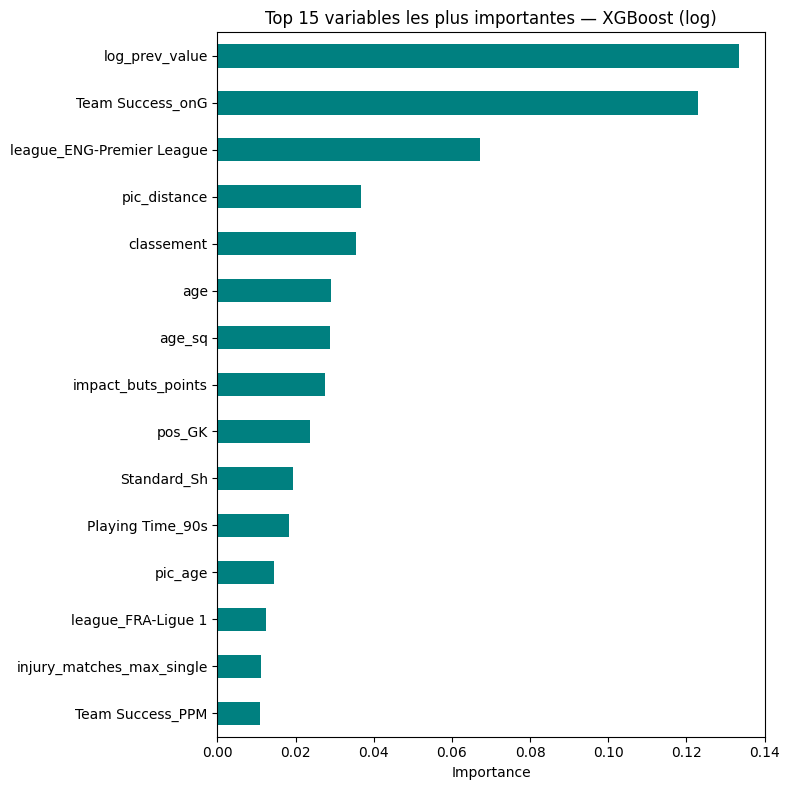

log_prev_value               0.133394
Team Success_onG             0.123055
league_ENG-Premier League    0.067191
pic_distance                 0.036707
classement                   0.035552
age                          0.028921
age_sq                       0.028678
impact_buts_points           0.027629
pos_GK                       0.023546
Standard_Sh                  0.019250
Playing Time_90s             0.018378
pic_age                      0.014532
league_FRA-Ligue 1           0.012325
injury_matches_max_single    0.011121
Team Success_PPM             0.010848
dtype: float32


In [145]:
imp_xgb = afficher_feature_importances(modele=modeles_tuned_log["XGBoost (log)"], feature_names=data["X_train"].columns,
                                       top_n=15, nom_modele="XGBoost (log)", color="teal")

### B4 : Normalisation / Standardisation de la variable cible

**Ce qu'on teste :** une transformation de la valeur marchande différente de `log1p` améliore-t-elle les performances ?

**Ce qui varie ici :** la transformation de la cible.  
**Ce qui reste fixe :** pipeline Bloc A, mêmes hyperparamètres XGBoost, même test.

Pour isoler l'effet de la transformation seule, on utilise le **même XGBoost** sans retuner. Ensuite, on retune avec la meilleure transformation pour voir son plein potentiel.

| Transformation | Description 
|---|---
| Brute | Aucune 
| `log1p` | log(1+y) 
| `log10` | log₁₀(y) 
| `sqrt` | √y
| Yeo-Johnson | Transformation optimale MLE 
| MinMax [0,1] | Normalisation linéaire
| Rang centile | Quantile uniforme

#### B4.1 : Visualisation des distributions

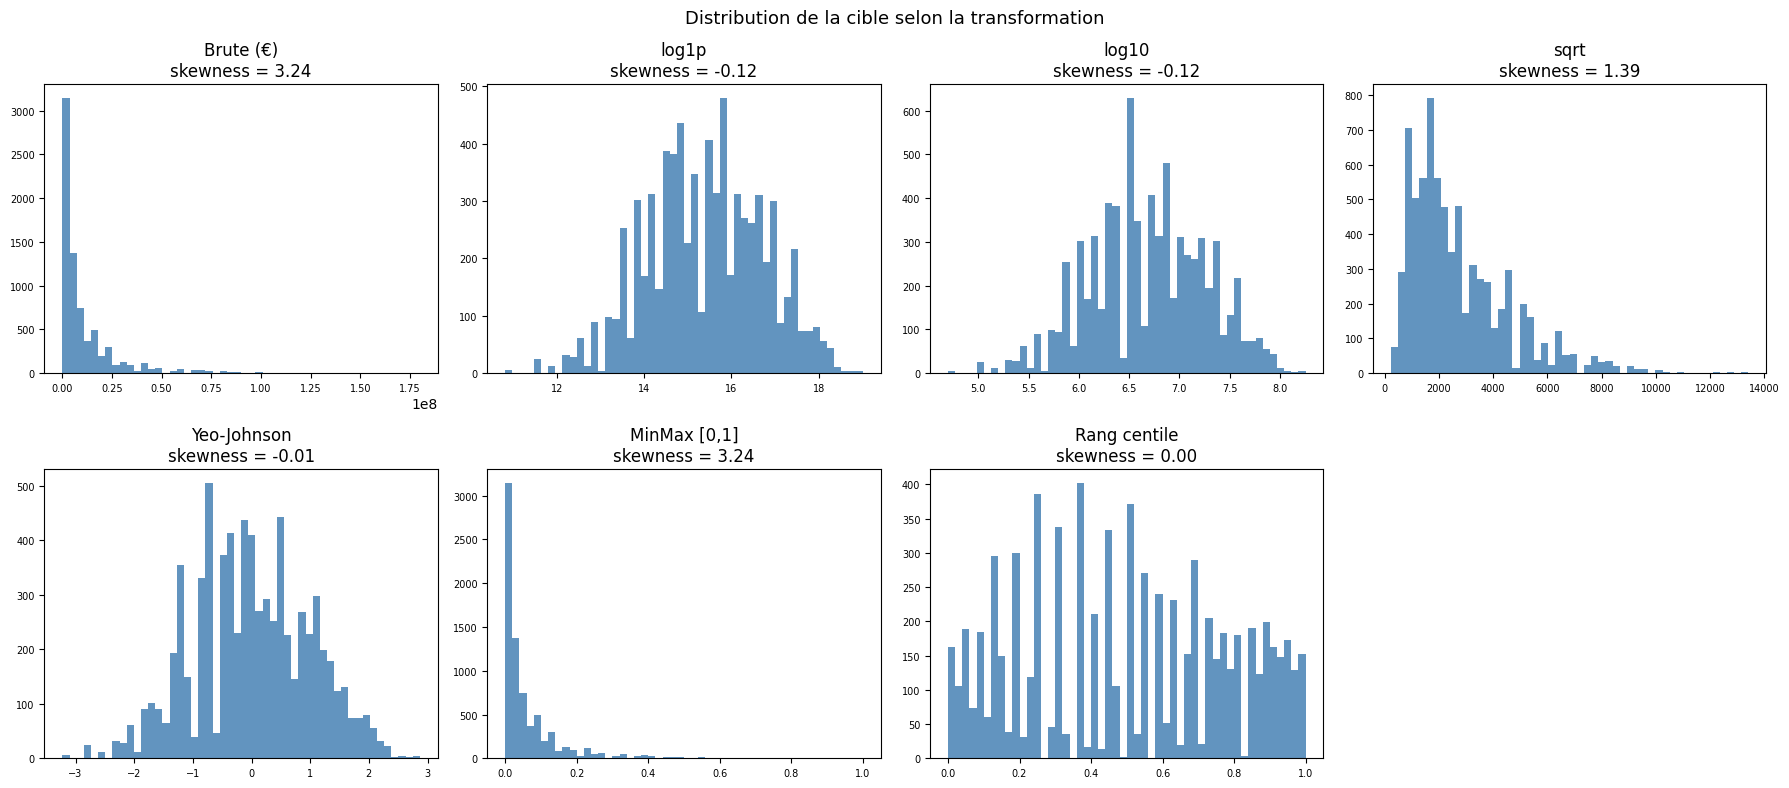

Statistiques de la cible brute :
count    7.404000e+03
mean     1.084476e+07
std      1.553714e+07
min      5.000000e+04
25%      2.000000e+06
50%      5.000000e+06
75%      1.400000e+07
max      1.800000e+08
Name: market_value_in_eur, dtype: float64


In [146]:
dict_transformations = analyser_transformations_cible(y_train=data["y_train"], random_state=RANDOM_STATE)

#### B4.2 : Définition des transformations et fonctions inverses

Pour chaque transformation, on définit :
- `transform(y)` : passe les euros en espace de modélisation
- `inverse(y_pred)` : retransforme les prédictions en euros pour le calcul des métriques

In [147]:
transformations = preparer_transformations_cible(y_train=data["y_train"], random_state=RANDOM_STATE)

y_train_log = transformations["log1p (baseline)"]["transform"](data["y_train"])
y_train_recup = transformations["log1p (baseline)"]["inverse"](y_train_log)

7 transformations définies.


#### B4.3 : Entraînement et évaluation pour chaque transformation

In [148]:
resultats, predictions_test = evaluer_transformations_stacking(transformations=transformations,
                                                               modeles_dict=modeles_tuned_log, data=data,
                                                               sample_weights_train=sample_weights_train, cv=5)


Brute (Stacking OOF)
  Aucune transformation. MAE en euros bruts.
  MAPE: 57.52% | R²: 0.9000 | MAE:  3,300,455€ | RMSE_log: 2.0744

log1p (baseline) (Stacking OOF)
  log(1+y) : transformation de référence.
  MAPE: 40.51% | R²: 0.8915 | MAE:  3,288,293€ | RMSE_log: 0.5256

log10 (Stacking OOF)
  log10(y) : espace plus lisible (6 = 1M€, 7 = 10M€).
  MAPE: 40.44% | R²: 0.8918 | MAE:  3,282,314€ | RMSE_log: 0.5255

sqrt (Stacking OOF)
  Racine carrée : compression plus douce que le log.
  MAPE: 45.61% | R²: 0.8955 | MAE:  3,190,579€ | RMSE_log: 0.5285

Yeo-Johnson (Stacking OOF)
  Box-Cox généralisée optimisée par maximum de vraisemblance.
  MAPE: 40.67% | R²: 0.8943 | MAE:  3,242,540€ | RMSE_log: 0.5240

MinMax [0,1] (Stacking OOF)
  Normalisation dans [0,1], sensible aux outliers.
  MAPE: 55.87% | R²: 0.8995 | MAE:  3,290,932€ | RMSE_log: 1.9542

Rang centile [0,1] (Stacking OOF)
  Transforme en rangs uniformes [0,1], robuste aux outliers.
  MAPE: 47.54% | R²: 0.4150 | MAE:  4,775,145€

#### B4.4 : Tableau comparatif par MAPE croissant

Classement par MAPE décroissant
                               MAE            RMSE    MAPE      R² RMSE_log
Transformation                                                             
log10                  3,282,314 €     6,143,946 €  40.44%  0.8918   0.5255
log1p (baseline)       3,288,293 €     6,153,946 €  40.51%  0.8915   0.5256
Yeo-Johnson            3,242,540 €     6,072,715 €  40.67%  0.8943   0.5240
sqrt                   3,190,579 €     6,039,549 €  45.61%  0.8955   0.5285
Rang centile [0,1]     4,775,145 €    14,288,894 €  47.54%  0.4150   0.5643
MinMax [0,1]           3,290,932 €     5,921,510 €  55.87%  0.8995   1.9542
Brute                  3,300,455 €     5,906,840 €  57.52%  0.9000   2.0744


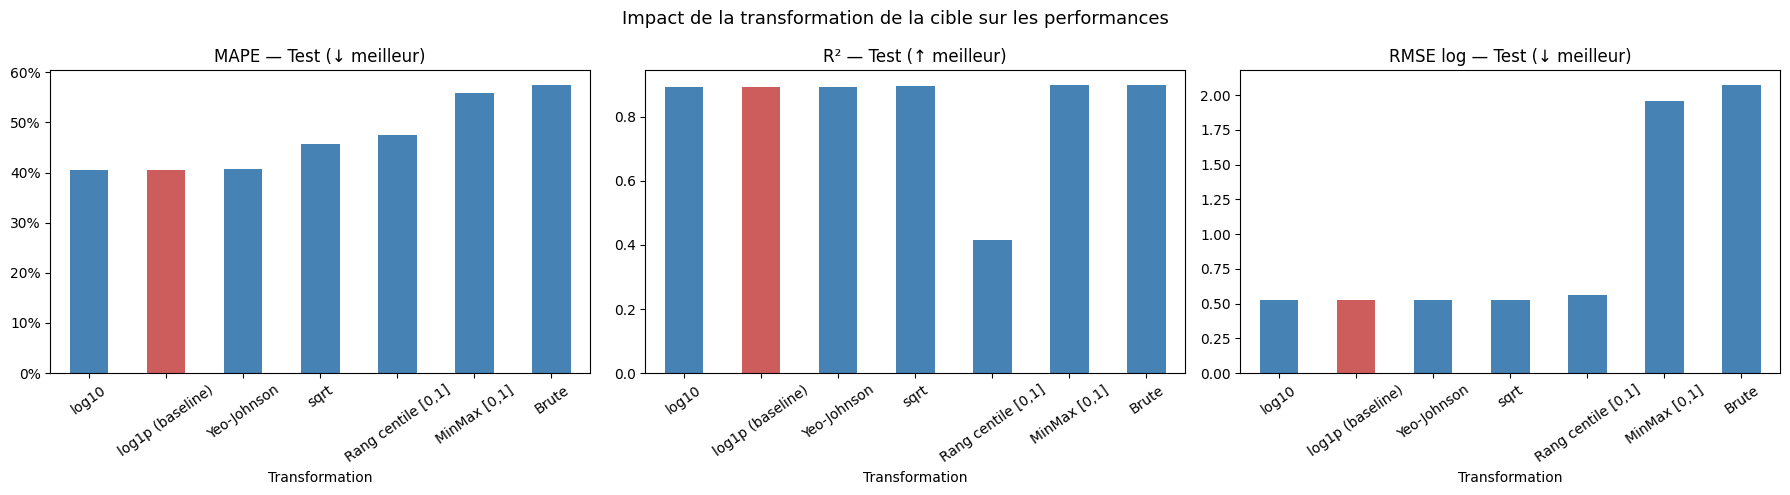

In [149]:
synthese = afficher_synthese_transformations(resultats)

#### B4.5 : Analyse par tranche de valeur

MAPE par tranche selon la transformation
Transformation                     <5M€   5–20M€  20–50M€    >50M€

Brute                             91.7%    31.2%    20.9%    16.7%
log1p (baseline)                  54.5%    32.0%    21.3%    20.2%
log10                             54.4%    31.9%    21.3%    20.0%
sqrt                              66.9%    30.5%    20.6%    18.0%
Yeo-Johnson                       55.2%    31.7%    21.1%    19.6%
MinMax [0,1]                      88.3%    31.1%    20.9%    16.9%
Rang centile [0,1]                64.6%    30.8%    28.6%    64.7%


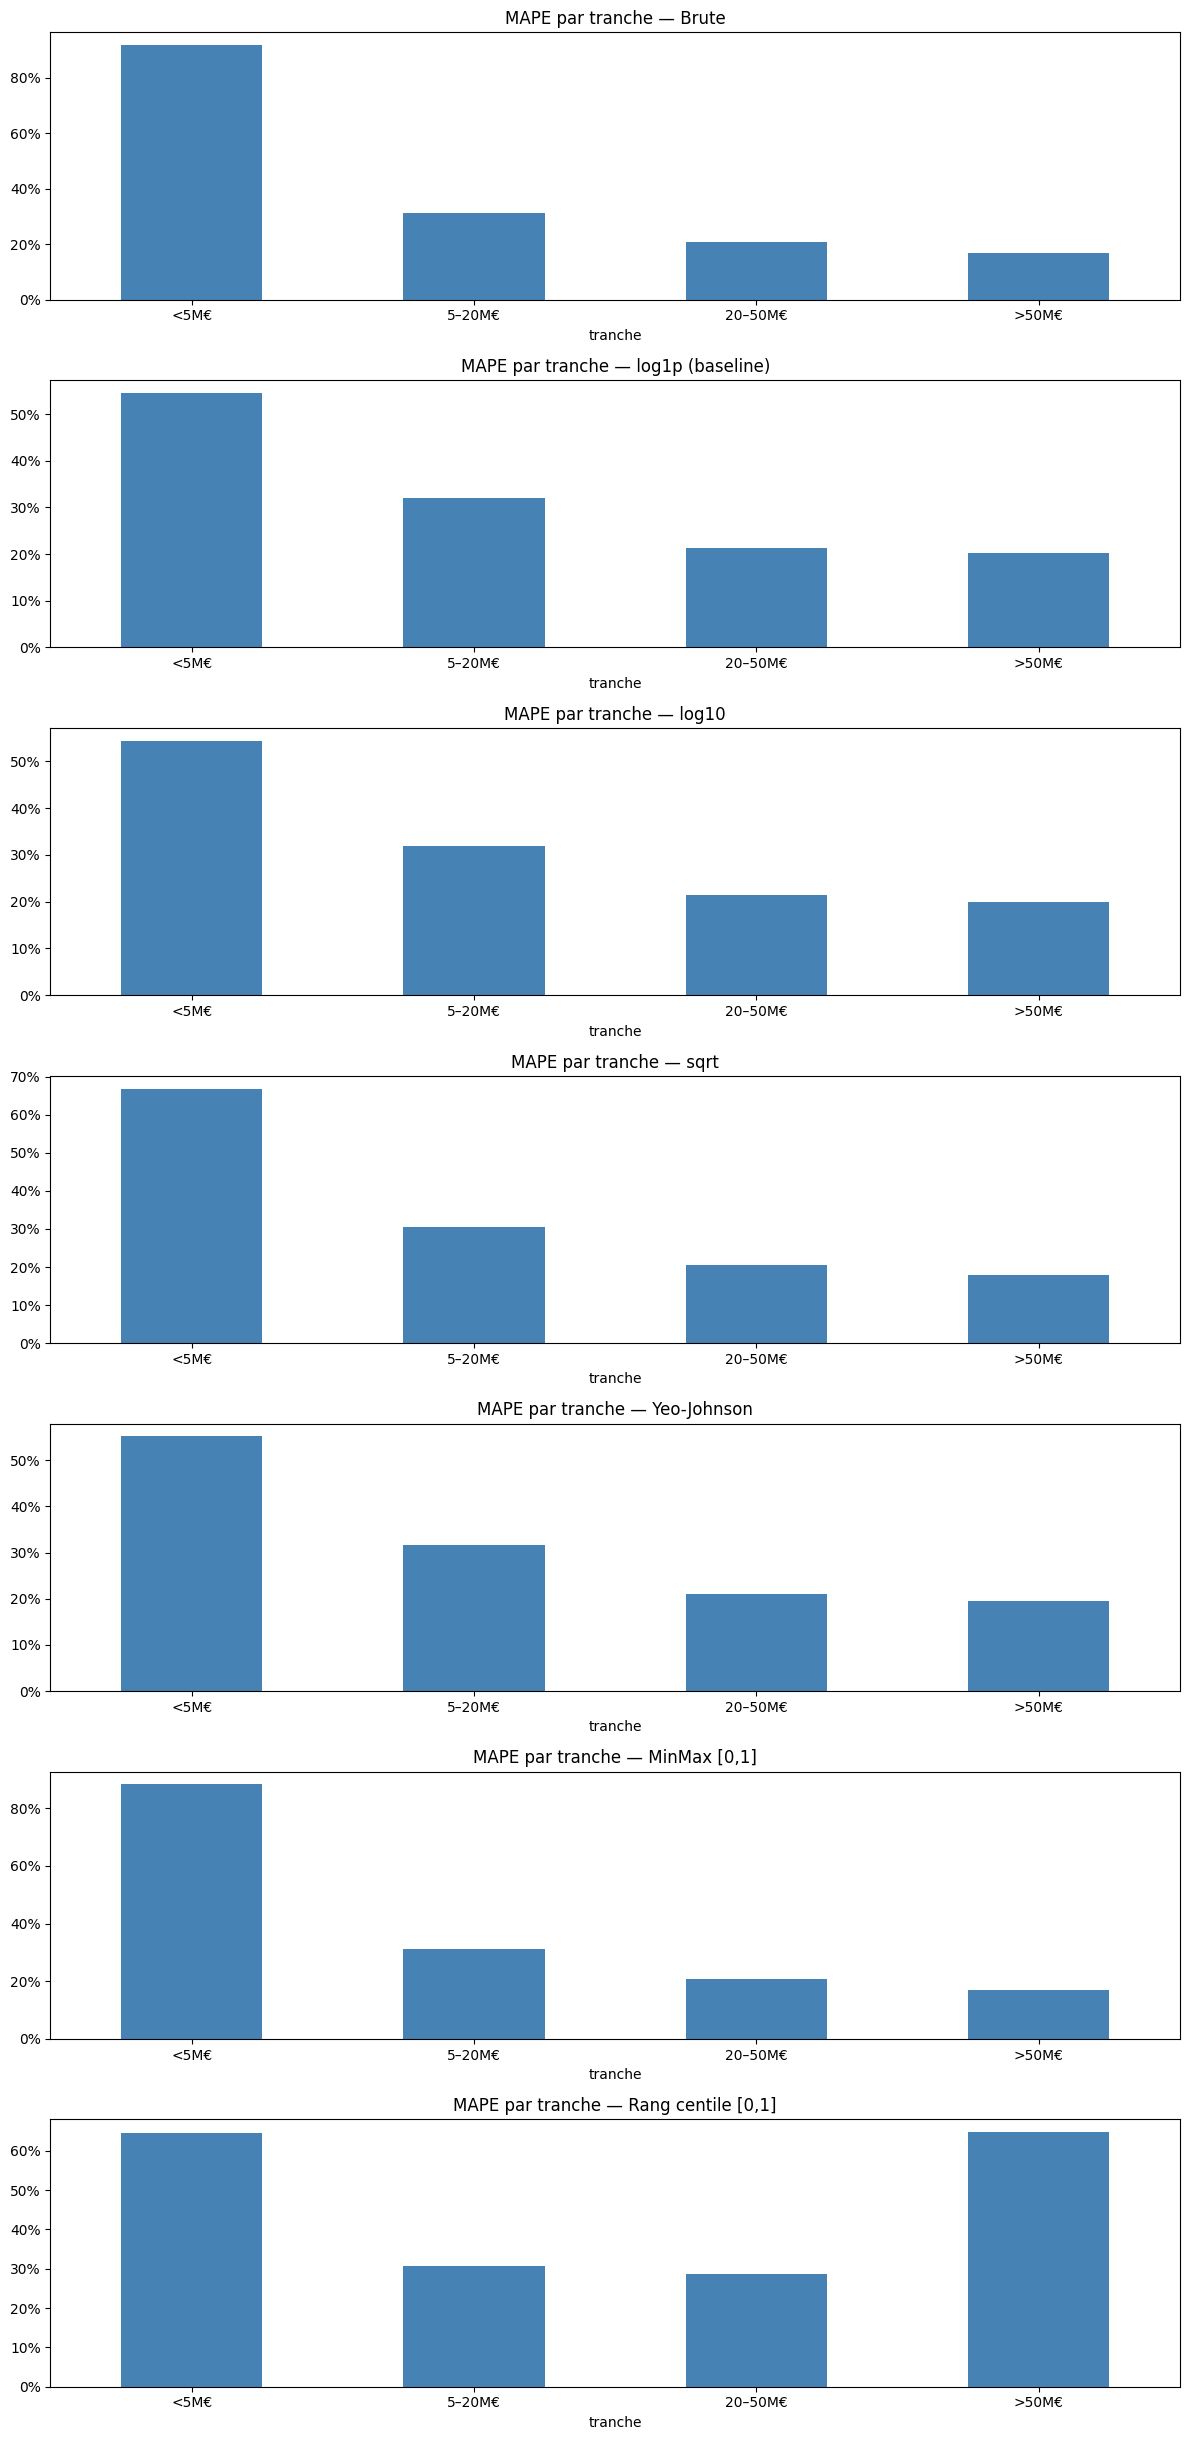

,<5M€,5–20M€,20–50M€,>50M€
Transformation,,,,
Brute,0.917455,0.312337,0.209193,0.166529
log1p (baseline),0.545181,0.319527,0.213301,0.201548
log10,0.543844,0.319276,0.213385,0.200380
sqrt,0.668807,0.304849,0.205970,0.179952
Yeo-Johnson,0.551714,0.316783,0.211050,0.195928
"MinMax [0,1]",0.883344,0.310967,0.208972,0.168555
"Rang centile [0,1]",0.646227,0.308256,0.286212,0.647446


In [150]:
analyser_mape_par_tranches(predictions_test=predictions_test, y_test=data["y_test"])

#### B4.6 : Tuning et Stacking OOF avec la meilleure transformation

On identifie la transformation qui minimise le MAPE, puis on retune XGBoost + LightGBM + CatBoost avec cette transformation et on construit le Stacking OOF final pour voir son plein potentiel.

In [151]:
best_transfo_data = preparer_meilleure_transformation(df_res=resultats, transformations=transformations,
                                                      y_train=data["y_train"], y_val=data.get("y_val", data["y_train"]),
                                                      y_test=data["y_test"], metric="MAPE")

# Récupération des cibles transformées pour le tuning ultérieur :
y_tr_best = best_transfo_data["y_tr_best"]
y_te_best = best_transfo_data["y_te_best"]

Sélection de la meilleure transformation (MAPE)
Meilleure transformation : log10
MAPE : 40.44%
R²   : 0.8918
MAE  :  3,282,314 €

Distribution de la cible transformée Train (log10) :
count    7404.000000
mean        6.690328
std         0.576314
min         4.698970
25%         6.301030
50%         6.698970
75%         7.146128
max         8.255273
Name: market_value_in_eur, dtype: float64


In [152]:
# On récupère la meilleure transformation sélectionnée
transfo_selected = best_transfo_data["transfo"]

study_xgb_best = optuna.create_study(direction="minimize")
study_xgb_best.optimize(
    lambda trial: tune_xgb(model_class=XGBRegressor, trial=trial, transfo=transfo_selected,
                           X_train=X_train, y_train=data["y_train"], X_val=X_val, y_val=data["y_val"], ),
    n_trials=N_TRIALS,
    show_progress_bar=True
)

print("Meilleurs hyperparamètres XGBoost :", study_xgb_best.best_params)

Best trial: 23. Best value: 5.6336e+06: 100%|██████████| 75/75 [23:12<00:00, 18.56s/it] 

Meilleurs hyperparamètres XGBoost : {'n_estimators': 2500, 'max_depth': 7, 'learning_rate': 0.011806150170171987, 'subsample': 0.7515115583982264, 'colsample_bytree': 0.8277354763019269, 'min_child_weight': 9.664569353002923, 'reg_alpha': 0.0006704142828413101, 'reg_lambda': 0.06763580563784702}


In [153]:
study_cat_best = optuna.create_study(direction="minimize")
study_cat_best.optimize(
    lambda trial: tune_catboost(model_class=CatBoostRegressor, trial=trial, transfo=transfo_selected,
                                X_train=X_train, y_train=data["y_train"], X_val=X_val, y_val=data["y_val"], ),
    n_trials=N_TRIALS,
    show_progress_bar=True
)

print("Meilleurs hyperparamètres CatBoost :", study_cat_best.best_params)

Best trial: 30. Best value: 5.98015e+06: 100%|██████████| 75/75 [57:58<00:00, 46.37s/it]   

Meilleurs hyperparamètres CatBoost : {'learning_rate': 0.011701825551685802, 'iterations': 9000, 'depth': 6, 'l2_leaf_reg': 4.72532077045894, 'subsample': 0.9439702370113929}


In [154]:
study_lgbm_best = optuna.create_study(direction="minimize")
study_lgbm_best.optimize(
    lambda trial: tune_lgbm(model_class=LGBMRegressor, trial=trial, transfo=transfo_selected,
                            X_train=X_train, y_train=data["y_train"], X_val=X_val, y_val=data["y_val"], ),
    n_trials=N_TRIALS,
    show_progress_bar=True
)

print("Meilleurs hyperparamètres LightGBM :", study_lgbm_best.best_params)

Best trial: 73. Best value: 5.83286e+06: 100%|██████████| 75/75 [25:44<00:00, 20.59s/it]

Meilleurs hyperparamètres LightGBM : {'n_estimators': 3500, 'num_leaves': 100, 'max_depth': 15, 'learning_rate': 0.0070945912031915, 'subsample': 0.7965132530576987, 'colsample_bytree': 0.9093219341853528, 'reg_alpha': 0.0001554367302706362, 'reg_lambda': 0.0007616940683915785}


In [155]:
# Instanciation de tes modèles avec les meilleurs hyperparamètres Optuna
modeles_f = {
    "XGBoost": XGBRegressor(**study_xgb_best.best_params, tree_method="hist",
                            enable_categorical=True, objective="reg:squarederror",
                            random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    "LightGBM": LGBMRegressor(**study_lgbm_best.best_params, random_state=RANDOM_STATE,
                              n_jobs=-1, verbose=-1),
    "CatBoost": CatBoostRegressor(**study_cat_best.best_params, bootstrap_type="Bernoulli",
                                  random_state=RANDOM_STATE, verbose=0),
}

# Lancement du pipeline complet
out_stacking = entrainer_et_evaluer_stacking_tuned(modeles_dict=modeles_f, transfo_dict=transformations,
                                                   meilleure_transfo_label=best_transfo_data["nom"],
                                                   data=data, sample_weights_train=sample_weights_train,
                                                   cv=5, n_jobs=-1, evaluer_fn=evaluer_complet)


resultats_nouveau = pd.DataFrame([out_stacking["resultat"]])
resultats = pd.concat([resultats, resultats_nouveau], ignore_index=True)

Génération OOF
  XGBoost: OOF MAPE = 42.69%
  LightGBM: OOF MAPE = 43.85%
  CatBoost: OOF MAPE = 42.19%
Poids : {'XGBoost': np.float64(0.342), 'LightGBM': np.float64(0.053), 'CatBoost': np.float64(0.614)}

Résultat final (Tuné + Stack (log10))
  MAPE     : 40.29%
  R²       : 0.8912
  MAE      :    3,272,824 €
  RMSE_log : 0.5254


#### B4.7 : Résultat final

In [156]:
# Modèle de référence optionnel
ref = {
    "Transformation": "log1p — modèle référence (tuné)",
    "MAPE": 0.3857,
    "R²": 0.880,
    "MAE": 3_340_118,
    "RMSE": None,
    "RMSE_log": 0.552,
}

# Appel de la fonction
df_classement_clean = afficher_classement_final(resultats=resultats, reference=ref, sort_by="MAPE", ascending=True)

Classement final
                                   MAPE      R²             MAE RMSE_log
Transformation                                                          
log1p — modèle référence (tuné)  38.57%  0.8800     3,340,118 €   0.5520
Tuné + Stack (log10)             40.29%  0.8912     3,272,824 €   0.5254
log10                            40.44%  0.8918     3,282,314 €   0.5255
log1p (baseline)                 40.51%  0.8915     3,288,293 €   0.5256
Yeo-Johnson                      40.67%  0.8943     3,242,540 €   0.5240
sqrt                             45.61%  0.8955     3,190,579 €   0.5285
Rang centile [0,1]               47.54%  0.4150     4,775,145 €   0.5643
MinMax [0,1]                     55.87%  0.8995     3,290,932 €   1.9542
Brute                            57.52%  0.9000     3,300,455 €   2.0744


### B5 : Retrait des valeurs extrêmes

**Ce qu'on teste :** retirer les valeurs marchandes extrêmes du train améliore-t-il les performances ?

**Ce qui varie ici :** le filtrage du train (seuil IQR).  
**Ce qui reste fixe :** pipeline Bloc A, même architecture (Stacking OOF, log1p), même test intouché.

**Hypothèse :** les joueurs > ~80M€ sont valorisés par des facteurs non capturés dans les stats (réputation médiatique, rareté, contexte de mercato). Leur présence dans le train peut biaiser l'apprentissage.

#### B5.1 : Chargement et identification des outliers

In [157]:
# Calcul des quartiles et de l'IQR uniquement sur le TRAIN
Q1 = df_train['market_value_in_eur'].quantile(0.25)
Q3 = df_train['market_value_in_eur'].quantile(0.75)
IQR = Q3 - Q1

# Définition du seuil supérieur uniquement
seuil_superieur = Q3 + 1.5 * IQR

# Filtrage : on ne garde que ce qui est inférieur ou égal au seuil maximum
df_train_b5 = df_train[df_train['market_value_in_eur'] <= seuil_superieur]
df_val_b5   = df_val[df_val['market_value_in_eur'] <= seuil_superieur]
df_test_b5  = df_test[df_test['market_value_in_eur'] <= seuil_superieur]

# Vérification du nombre de lignes supprimées
print(f"Seuil max appliqué : {seuil_superieur:.0f} €")
print(f"Lignes supprimées dans Train : {len(df_train) - len(df_train_b5)}")
print(f"Lignes supprimées dans Val   : {len(df_val) - len(df_val_b5)}")
print(f"Lignes supprimées dans Test  : {len(df_test) - len(df_test_b5)}")

Seuil max appliqué : 32000000 €
Lignes supprimées dans Train : 570
Lignes supprimées dans Val   : 224
Lignes supprimées dans Test  : 216


#### B5.2 : Préparation des jeux X / y

In [158]:
data_b5 = preparer_donnees(df_train_b5, df_val_b5, df_test_b5, colonne_cible)

# Extraction de toutes les variables du dictionnaire
X_train_b5 = data_b5["X_train"]
y_train_b5 = data_b5["y_train"]
y_train_log_b5 = data_b5["y_train_log"]
sample_weights_train_b5 = data_b5["sample_weights_train"]

X_val_b5 = data_b5["X_val"]
y_val_b5 = data_b5["y_val"]
y_val_log_b5 = data_b5["y_val_log"]

X_test_b5 = data_b5["X_test"]
y_test_b5 = data_b5["y_test"]
y_test_log_b5 = data_b5["y_test_log"]

X_train_sans_nan_b5 = data_b5["X_train_sans_nan"]
X_val_sans_nan_b5 = data_b5["X_val_sans_nan"]
X_test_sans_nan_b5 = data_b5["X_test_sans_nan"]


X_train : (6834, 146) | X_val : (2207, 146) | X_test : (2079, 146)
Filtrage pour les modèles linéaires/SVR :
137 colonnes conservées sur 146.


#### B5.3 : Tuning des hyperparamètres

In [159]:
study_xgb_log_b5 = optuna.create_study( direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))

study_xgb_log_b5.optimize(
    lambda t: tune_xgb(XGBRegressor, t, transfo={"transform": np.log1p, "inverse": np.expm1}, random_state=RANDOM_STATE,
                        X_train=X_train_b5, y_train=y_train_b5, X_val=X_val_b5, y_val=y_val_b5),
                        n_trials=N_TRIALS,
    show_progress_bar=True,
)

print("Meilleur RMSE :", study_xgb_log_b5.best_value)
print("Meilleurs paramètres :", study_xgb_log_b5.best_params)

Best trial: 54. Best value: 3.52459e+06: 100%|██████████| 75/75 [38:29<00:00, 30.79s/it]

Meilleur RMSE : 3524586.63744968
Meilleurs paramètres : {'n_estimators': 2500, 'max_depth': 10, 'learning_rate': 0.011075583050655462, 'subsample': 0.573027142459079, 'colsample_bytree': 0.8628962164854356, 'min_child_weight': 9.821810821824858, 'reg_alpha': 0.0003587012955989072, 'reg_lambda': 0.07725852054518159}


In [160]:
study_lgbm_log_b5 = optuna.create_study( direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))

study_lgbm_log_b5.optimize(
    lambda t: tune_lgbm(LGBMRegressor, t, transfo={"transform": np.log1p, "inverse": np.expm1}, random_state=RANDOM_STATE,
                       X_train=X_train_b5, y_train=y_train_b5, X_val=X_val_b5, y_val=y_val_b5),
    n_trials=N_TRIALS,
    show_progress_bar=True,
)

print("Meilleur RMSE :", study_lgbm_log_b5.best_value)
print("Meilleurs paramètres :", study_lgbm_log_b5.best_params)

Best trial: 14. Best value: 3.5275e+06: 100%|██████████| 75/75 [19:02<00:00, 15.23s/it]

Meilleur RMSE : 3527496.4626618726
Meilleurs paramètres : {'n_estimators': 3250, 'num_leaves': 91, 'max_depth': 14, 'learning_rate': 0.005156238652696661, 'subsample': 0.8891877229502084, 'colsample_bytree': 0.6878518032408123, 'reg_alpha': 0.0034788136899577726, 'reg_lambda': 1.1936127772212226}


In [161]:
study_cat_log_b5 = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_cat_log_b5.optimize(
    lambda t: tune_catboost(CatBoostRegressor, t, transfo={"transform": np.log1p, "inverse": np.expm1}, random_state=RANDOM_STATE,
                            X_train=X_train, y_train=y_train,
                            X_val=X_val, y_val=y_val),
    n_trials=N_TRIALS,
    show_progress_bar=True,
)
print("Meilleur RMSE :", study_cat_log_b5.best_value)
print("Meilleurs paramètres :", study_cat_log_b5.best_params)

Best trial: 23. Best value: 5.94397e+06: 100%|██████████| 75/75 [1:01:49<00:00, 49.46s/it]

Meilleur RMSE : 5943972.454026171
Meilleurs paramètres : {'learning_rate': 0.023320965394393704, 'iterations': 7000, 'depth': 6, 'l2_leaf_reg': 5.587329906441078, 'subsample': 0.993817408333189}


#### B5.4 : Modèles finaux et évaluation validation

In [162]:
xgb_final = XGBRegressor(
    **study_xgb_log_b5.best_params,
    tree_method="hist", enable_categorical=True,
    objective="reg:squarederror",
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
lgbm_final = LGBMRegressor(
    **study_lgbm_log_b5.best_params,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
cat_final = CatBoostRegressor(
    **study_cat_log_b5.best_params,
    bootstrap_type="Bernoulli",
    random_state=RANDOM_STATE, early_stopping_rounds=50, verbose=0
)

modeles_finaux = {
    "XGBoost":   xgb_final,
    "LightGBM":  lgbm_final,
    "CatBoost":  cat_final,
}

In [163]:
evaluer_modeles_tuned(modeles_finaux, modeles_tuned_sans_nan = None, data=data_b5, mode="val", use_log=True)

Entraînement (tuné) de XGBoost...
Entraînement (tuné) de LightGBM...
Entraînement (tuné) de CatBoost...

Classement (Validation, modèles tunés)
                   MAE          RMSE      MAPE        R2  R2 Ajusté
LightGBM  2.155167e+06  3.527496e+06  0.440471  0.785008   0.769770
XGBoost   2.161292e+06  3.524587e+06  0.442372  0.785362   0.770150
CatBoost  2.221251e+06  3.599996e+06  0.448583  0.776080   0.760209


,MAE,RMSE,MAPE,R2,R2 Ajusté
LightGBM,2.155167e+06,3.527496e+06,0.440471,0.785008,0.769770
XGBoost,2.161292e+06,3.524587e+06,0.442372,0.785362,0.770150
CatBoost,2.221251e+06,3.599996e+06,0.448583,0.776080,0.760209


#### B5.5 : Stacking OOF

In [164]:
base_models_b5 = ["XGBoost", "LightGBM", "CatBoost"]

# Génération des méta-features
X_meta_train_b5, X_meta_val_b5, X_meta_test_b5, temps_fit_b5 = preparer_meta_features(
    base_models_names=base_models_b5, modeles_dict=modeles_finaux, data=data_b5
)

Génération des OOF predictions (cross_val_predict, cv=5)...
  XGBoost : OOF RMSE = 3,508,695 € (111.0s)
  LightGBM : OOF RMSE = 3,492,508 € (110.3s)
  CatBoost : OOF RMSE = 3,533,586 € (218.9s)


In [165]:
# Évaluation des ensembles et récupération des prédictions

pred_val_moyenne_b5, pred_test_moyenne_b5, pred_val_stack_b5, pred_test_stack_b5, meta_modele_b5, comparaison_blend_b5 = evaluer_ensembles(X_meta_train_b5, X_meta_val_b5, X_meta_test_b5, data=data_b5, modeles_tuned_log=modeles_finaux, nom_modele_seul="CatBoost")

Blend (moyenne simple)
  Val  -> MAE : 2,121,502 € | R² : 0.7922
  Test -> MAE : 2,307,019 € | R² : 0.7944

Poids appris par le méta-modèle : {'XGBoost': np.float64(0.298), 'LightGBM': np.float64(0.459), 'CatBoost': np.float64(0.297)}
Intercept : 329,641 €

Stacking OOF (méta-modèle)
  Val  -> MAE : 2,099,629 € | R² : 0.8087
  Test -> MAE : 2,293,835 € | R² : 0.8103

                           MAE Val    R2 Val      MAE Test   R2 Test
Blend (stacking OOF)  2.099629e+06  0.808684  2.293835e+06  0.810300
Blend (moyenne)       2.121502e+06  0.792233  2.307019e+06  0.794367
CatBoost seul         2.221251e+06  0.776080  2.437729e+06  0.772472


#### B5.6 : Analyse par tranche et visualisations

         n_joueurs  valeur_moyenne           MAE      MAPE  \
tranche                                                      
<5M€          1075    2.417744e+06  1.061556e+06  0.764386   
5-20M€         795    1.164088e+07  3.214629e+06  0.293391   
20-50M€        209    2.655024e+07  5.129566e+06  0.192781   

         % du total joueurs  % de l'erreur absolue totale  
tranche                                                    
<5M€              51.707552                     23.929568  
5-20M€            38.239538                     53.589706  
20-50M€           10.052910                     22.480726  


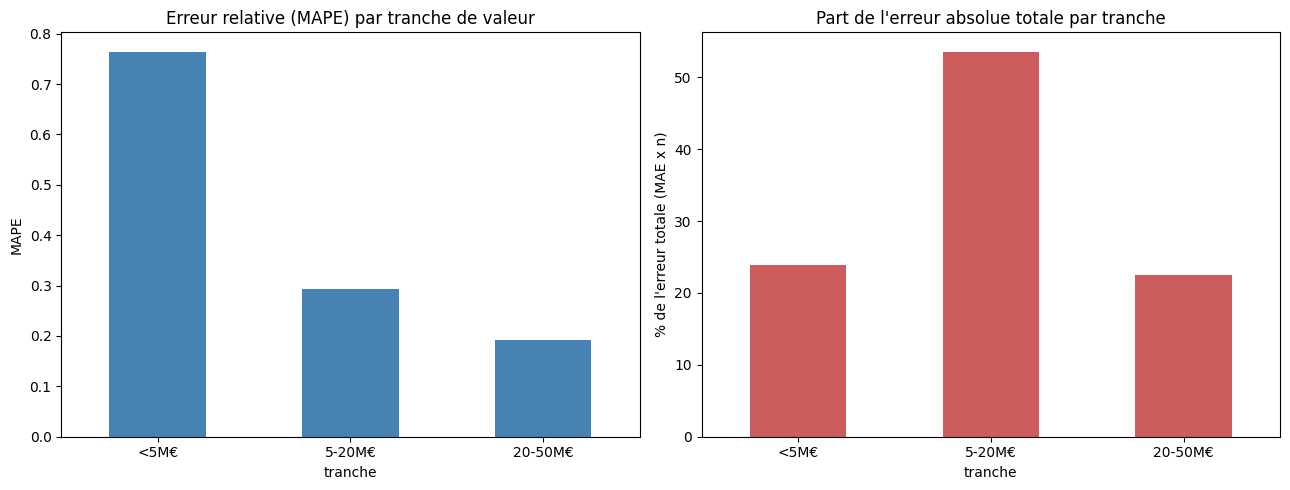

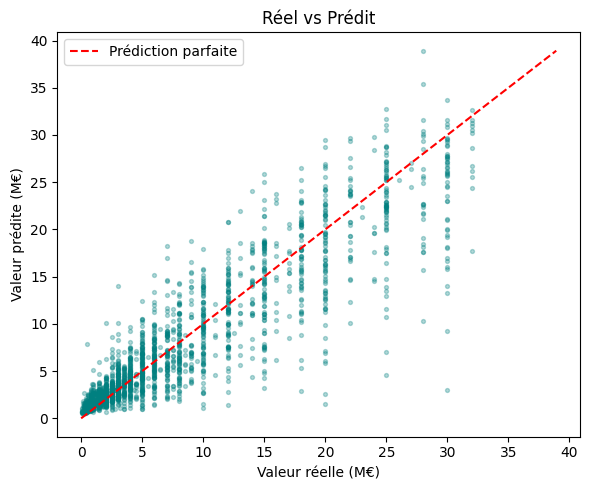

In [166]:
synthese_tranches = analyser_erreurs_par_tranches(y_test=data_b5["y_test"],
                                                  meilleure_prediction_test=pred_test_stack_b5,
                                                  random_state=RANDOM_STATE)

#### B5.7 : Feature importance (XGBoost)

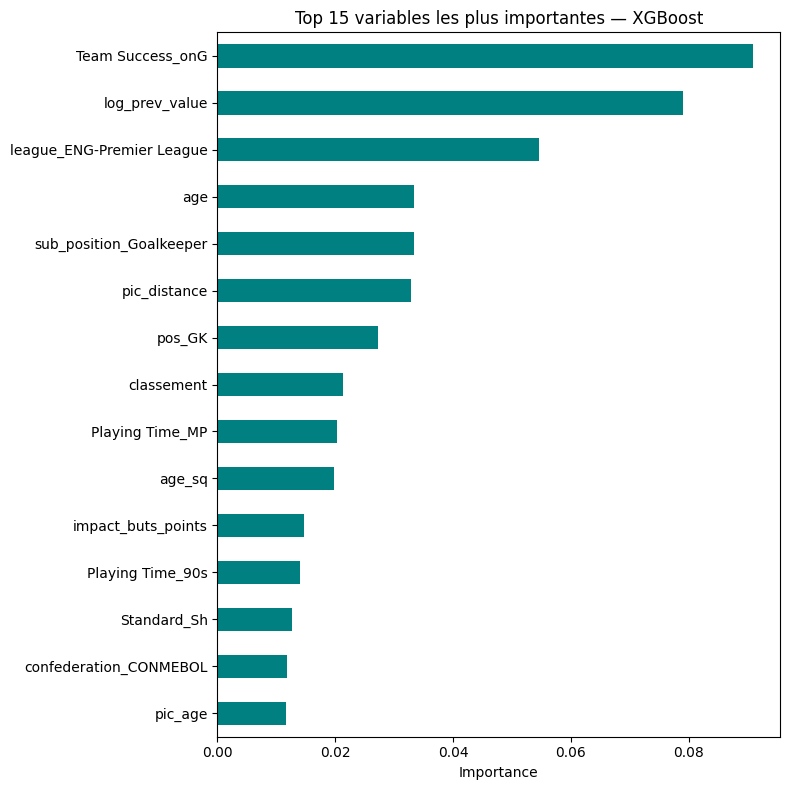

Team Success_onG             0.090963
log_prev_value               0.079003
league_ENG-Premier League    0.054550
age                          0.033397
sub_position_Goalkeeper      0.033295
pic_distance                 0.032907
pos_GK                       0.027195
classement                   0.021316
Playing Time_MP              0.020269
age_sq                       0.019792
impact_buts_points           0.014619
Playing Time_90s             0.013946
Standard_Sh                  0.012592
confederation_CONMEBOL       0.011882
pic_age                      0.011698
dtype: float32


In [167]:
imp_xgb = afficher_feature_importances(modele=modeles_finaux["XGBoost"], feature_names=data_b5["X_train"].columns,
                                       top_n=15, nom_modele="XGBoost", color="teal")

### B6 : Réduction de dimensionnalité

**Ce qu'on teste :** réduire le nombre de features améliore-t-il les performances ?

**Ce qui varie ici :** le nombre et la sélection des features.  
**Ce qui reste fixe :** pipeline Bloc A, même architecture (Stacking OOF, log1p), même test.

| Approche | Principe | Interprétabilité | Biais |
|---|---|---|---|
| **ACP 95%/99%/99.9%** | Composantes orthogonales classées par variance | Non | Non |
| **Sélection gain** top 50/75/100 | Features les plus importantes (XGBoost) | Oui | Haute cardinalité |
| **Permutation Importance** > 0/0.001/0.005 | Dégradation réelle si la feature est mélangée | Oui | Non biaisée |

#### B6.1 — Baseline de référence

On évalue d'abord le Stacking OOF **sans réduction** pour avoir un point de comparaison objectif. Toute approche qui fait moins bien que cette baseline n'apporte rien.

In [168]:
xgb = XGBRegressor( random_state=1308, n_jobs=-1, n_estimators=100, learning_rate=0.1 )
lgbm = LGBMRegressor( random_state=1308, n_jobs=-1, n_estimators=100, learning_rate=0.1, verbose=-1 )
cat  = CatBoostRegressor( random_state=1308, iterations=100, learning_rate=0.1, verbose=0 )

print("Entraînement baseline (sans réduction)...")
pred_val_base, pred_test_base, modeles_base = entrainer_stack(xgb, lgbm, cat,
    X_train, y_train_log, X_val, y_val_log, X_test, y_val, w=sample_weights_train)

res_base = evaluer_complet("Sans réduction", y_test, pred_test_base)
print(f"  MAPE : {res_base['MAPE']:.2%} | R² : {res_base['R²']:.4f} | RMSE_log : {res_base['RMSE_log']:.4f}")
resultats_comparaison = [res_base]

Entraînement baseline (sans réduction)...
  MAPE : 40.34% | R² : 0.8625 | RMSE_log : 0.5369


#### B6.2 : ACP (Analyse en Composantes Principales)

**Étapes :**
1. Imputation des NaN résiduels par la médiane (nécessaire avant StandardScaler)
2. Standardisation
3. Calcul de la variance expliquée cumulée
4. Test de 3 seuils : 95%, 99%, 99.9% de variance conservée

NaN restants — train: 0 | val: 0 | test: 0
Dimensions originales : 146 features
Composantes pour 95%  de variance : 81
Composantes pour 99%  de variance : 105
Composantes pour 99.9% de variance : 122


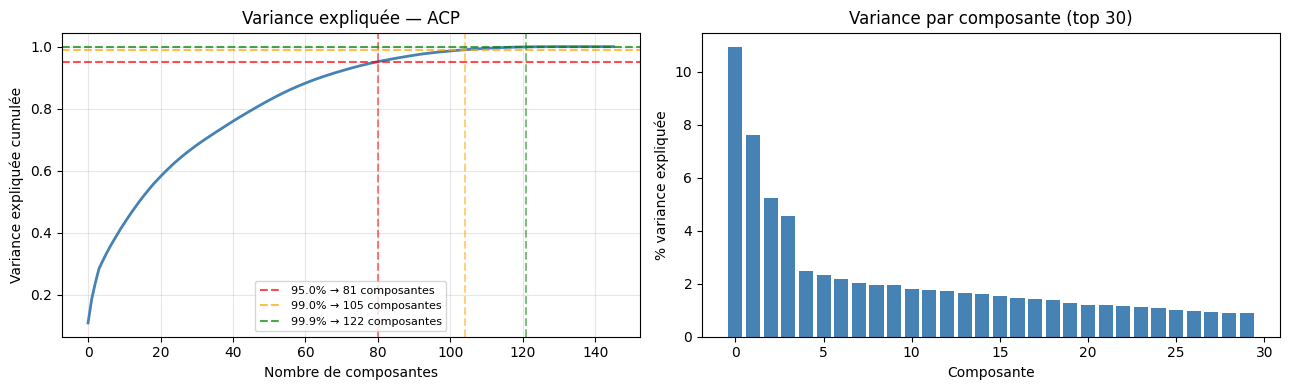

In [169]:
res_pca = preprocess_and_evaluate_pca(X_train, X_val, X_test)

In [170]:
# Modèles de base à passer en paramètre
modeles_base = (xgb, lgbm, cat)

# Exécution de la fonction
nouveaux_resultats = evaluer_acp_seuils(
    X_train_scaled=res_pca["X_train_scaled"],
    X_val_scaled=res_pca["X_val_scaled"],
    X_test_scaled=res_pca["X_test_scaled"],
    y_train_log=y_train_log,
    y_val_log=y_val_log,
    y_val=y_val,
    y_test=y_test,
    sample_weights_train=sample_weights_train,
    modeles_base=modeles_base,
    res_pca=res_pca,
    random_state=1308,
)

# Fusion des résultats avec tes métriques globales
resultats_comparaison.extend(nouveaux_resultats)


ACP 95.0% (81 composantes)
  MAPE : 58.50% | R² : 0.7749 | RMSE_log : 0.6488

ACP 99.0% (105 composantes)
  MAPE : 58.41% | R² : 0.7693 | RMSE_log : 0.6521

ACP 99.9% (122 composantes)
  MAPE : 58.53% | R² : 0.7752 | RMSE_log : 0.6480


#### B6.3 : Sélection par importance XGBoost (gain)

On entraîne un XGBoost rapide pour extraire l'importance par gain de chaque feature, puis on garde les top N les plus importantes.

⚠️ **Attention :** l'importance par gain est biaisée : elle tend à sur-estimer les features à haute cardinalité (comme les variables continues) par rapport aux variables binaires.

Features total : 146
Features avec importance > 0     : 137
Features avec importance > 0.01 (1%) : 16
Features avec importance > 0.005 (0.5%) : 26

Top 20 features :
Team Success_onG             0.177551
log_prev_value               0.176415
league_ENG-Premier League    0.040920
classement                   0.037887
impact_buts_points           0.032467
pic_age                      0.027882
age                          0.027169
pos_GK                       0.020958
Standard_Sh                  0.018724
injury_matches_max_single    0.014229
league_FRA-Ligue 1           0.013425
confederation_CONMEBOL       0.012069
injury_musculaire            0.011622
season_year                  0.011341
injury_genou                 0.010757
taux_indisponibilite_prec    0.010606
est_polyvalent               0.009921
Team Success_PPM             0.009778
sub_position_Right-Back      0.008113
Playing Time_MP              0.008023


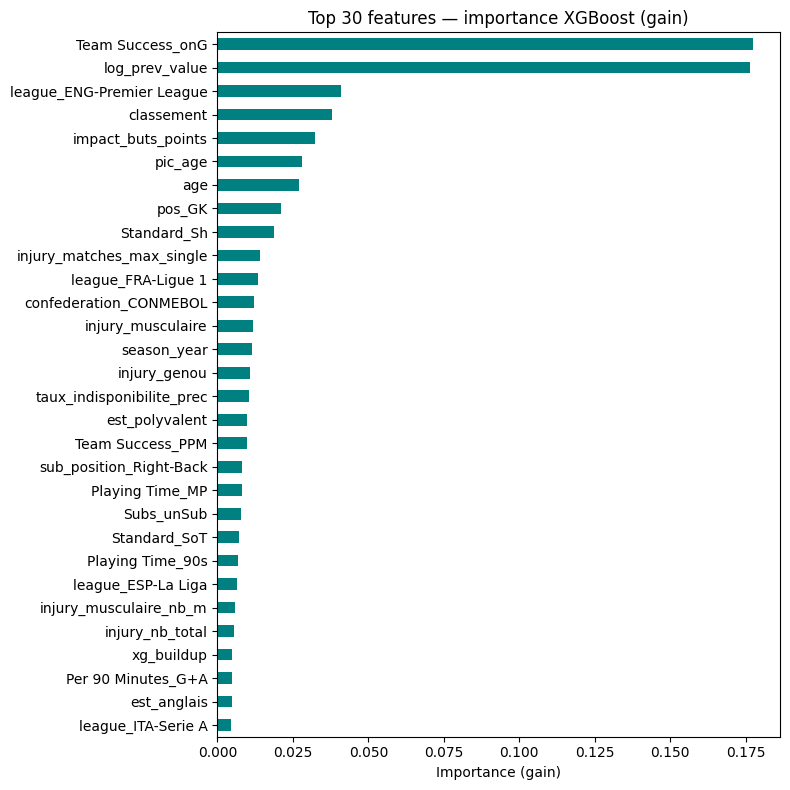

In [171]:
selector_model = XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.1, tree_method="hist",
                              enable_categorical=True, objective="reg:squarederror", random_state=RANDOM_STATE,
                              n_jobs=-1, verbosity=0)

importances = calculer_importances_xgboost(selector_model, X_train=X_train, y_train_log=y_train_log,
                                           sample_weights_train=sample_weights_train, top_n_plot=30,
                                           random_state=RANDOM_STATE)

#### B6.4 : Permutation importance

La permutation importance mélange aléatoirement chaque feature une par une sur le jeu de **validation** (pas le train, mémorisé par les arbres) et mesure la dégradation de performance. Elle est **non biaisée** et capture l'impact réel sur les prédictions.

Calcul permutation importance (peut prendre 2-3 minutes)...

Features avec permutation importance > 0   : 99
Features avec permutation importance < 0   : 35 (mélanger améliore → bruit)

Top 30 permutation importance :
log_prev_value                   0.653654
age                              0.386007
Team Success_onG                 0.308765
classement                       0.075458
league_ENG-Premier League        0.069855
Team Success_onGA                0.036072
Playing Time_MP                  0.022548
Playing Time_90s                 0.016455
Subs_unSub                       0.014220
impact_buts_points               0.011825
Performance_Fls                  0.011398
Playing Time_Starts              0.011211
Playing Time_Mn/MP               0.007323
league_FRA-Ligue 1               0.007245
Team Success_On-Off              0.006806
contribution_offensive_equipe    0.005805
Standard_Sh                      0.004373
pic_age                          0.003650
Team Success_PPM          

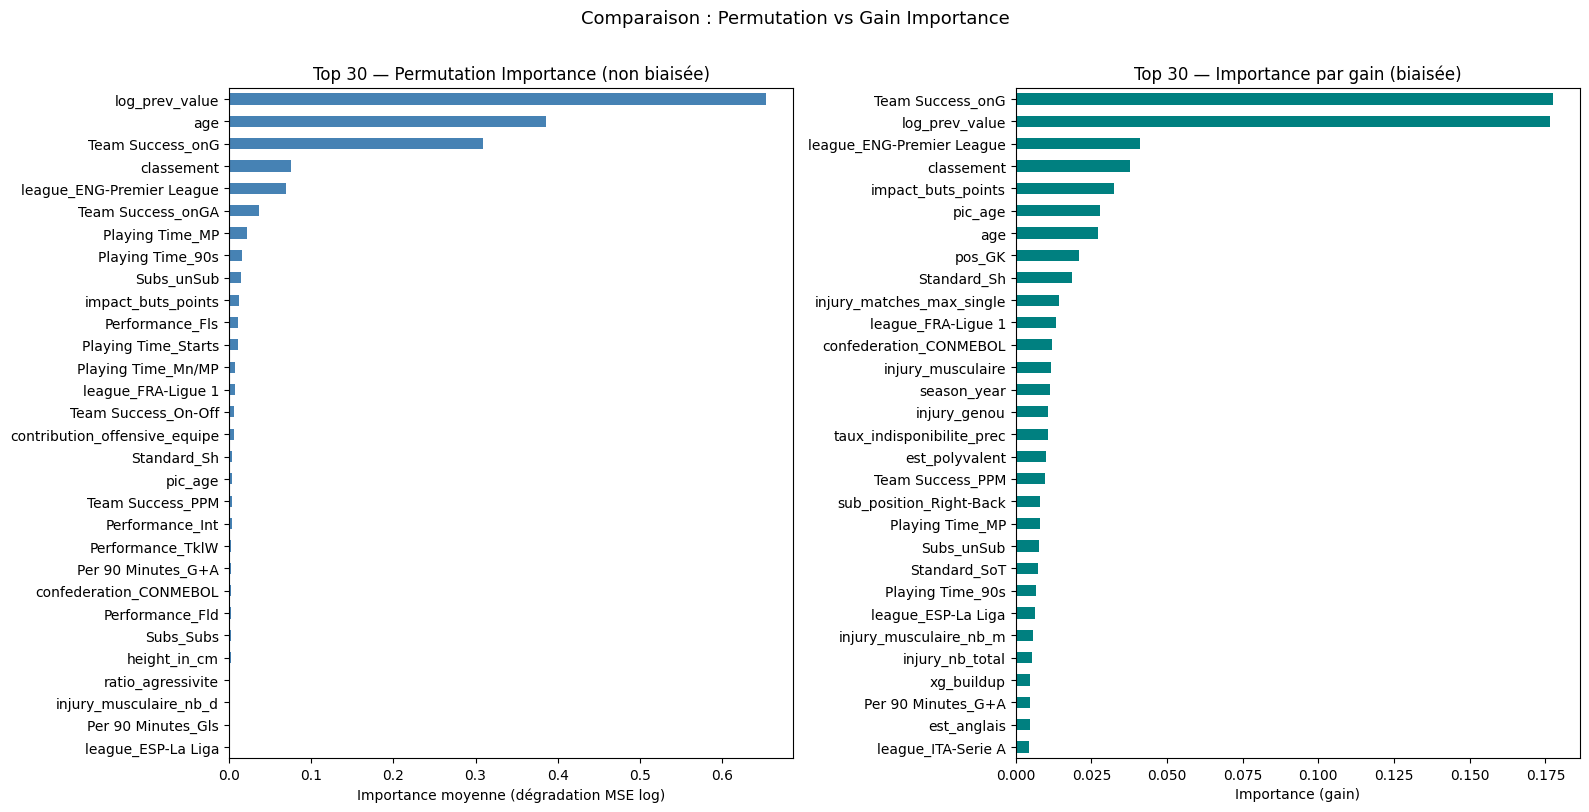

In [172]:
perm_imp, perm_std = comparer_permutation_vs_gain_importance(selector_model, X_val, y_val_log,
                                                             importances_gain=importances, top_n=30, n_repeats=10,
                                                             random_state=RANDOM_STATE, n_jobs=-1)

In [173]:
# Modèles de base à transmettre
modeles_base = (xgb, lgbm, cat)

# Exécution du filtrage par permutation
nouveaux_resultats, dict_features = evaluer_selection_permutation(perm_imp=perm_imp, X_train=X_train,
                                                                  y_train_log=y_train_log, X_val=X_val,
                                                                  y_val_log=y_val_log, X_test=X_test, y_val=y_val,
                                                                  y_test=y_test, sample_weights_train=sample_weights_train,
                                                                  modeles_base=modeles_base)

# Ajout aux résultats globaux de comparaison
resultats_comparaison.extend(nouveaux_resultats)


Perm > 0  (toutes utiles) (99 features)
  MAPE : 41.06% | R² : 0.8601 | RMSE_log : 0.5255

Perm > 0.001 (35 features)
  MAPE : 41.23% | R² : 0.8539 | RMSE_log : 0.5291

Perm > 0.005 (16 features)
  MAPE : 41.84% | R² : 0.8472 | RMSE_log : 0.5411


#### B6.5 : Tableau comparatif final

Comparaison finale sur le test
                                      MAE            RMSE    MAPE      R² RMSE_log
Label                                                                             
Sans réduction             >>>3,468,145 €  >>>6,927,314 €  40.34%  0.8625   0.5369
ACP 95.0%                  >>>4,622,164 €  >>>8,862,528 €  58.50%  0.7749   0.6488
ACP 99.0%                  >>>4,726,502 €  >>>8,972,836 €  58.41%  0.7693   0.6521
ACP 99.9%                  >>>4,656,966 €  >>>8,857,422 €  58.53%  0.7752   0.6480
Perm > 0  (toutes utiles)  >>>3,435,039 €  >>>6,987,458 €  41.06%  0.8601   0.5255
Perm > 0.001               >>>3,447,826 €  >>>7,141,651 €  41.23%  0.8539   0.5291
Perm > 0.005               >>>3,522,743 €  >>>7,301,377 €  41.84%  0.8472   0.5411


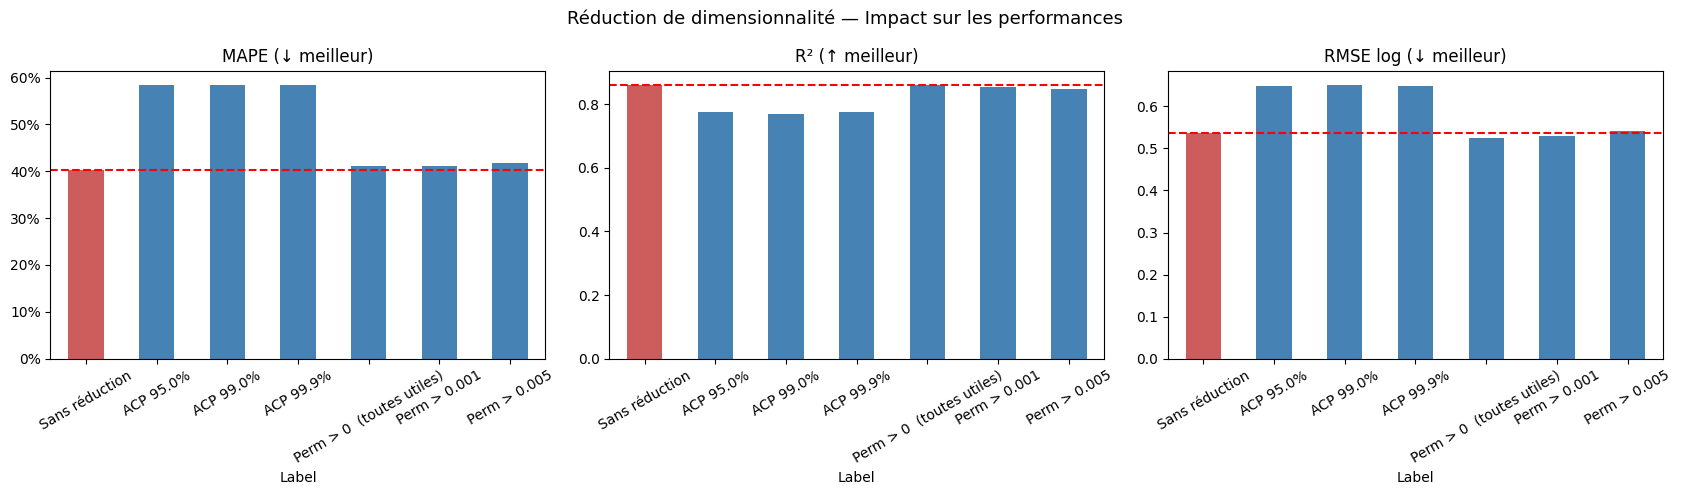

In [174]:
df_recap = afficher_comparaison_finale(resultats_comparaison, label_baseline="Sans")

### B7 : Modèles séparés : Gardiens / Joueurs de champ

**Ce qu'on teste :** spécialiser un modèle par position améliore-t-il les performances ?

**Ce qui varie ici :** la population d'entraînement (GK ou joueurs de champ).  
**Ce qui reste fixe :** pipeline Bloc A, même architecture (Stacking OOF, log1p), même test.

**Hypothèse :** les gardiens ont des stats fondamentalement différentes (saves, CS%, SoTA...) des joueurs de champ (buts, xG, dribbles...). Un modèle unique fait des compromis.

#### B7.1 : Séparation des populations

In [175]:
# Dépaquetage complet en une ligne
data_split = separer_gardiens_et_champ(X_train, y_train, X_val, y_val, X_test, y_test)

# Gardiens
X_train_gk_feat = data_split["gk"]["X_train"]
y_train_gk = data_split["gk"]["y_train"]
X_val_gk_feat = data_split["gk"]["X_val"]
y_val_gk = data_split["gk"]["y_val"]
X_test_gk_feat = data_split["gk"]["X_test"]
y_test_gk = data_split["gk"]["y_test"]

# Joueurs de champ
X_train_champ_feat = data_split["champ"]["X_train"]
y_train_champ = data_split["champ"]["y_train"]
X_val_champ_feat = data_split["champ"]["X_val"]
y_val_champ = data_split["champ"]["y_val"]
X_test_champ_feat = data_split["champ"]["X_test"]
y_test_champ = data_split["champ"]["y_test"]

Gardiens         :   567 train |  180 val |  172 test
Joueurs de champ :  6837 train | 2251 val | 2123 test


#### B7.2 : Tuning par groupe

On utilise `N_TRIALS_SPLIT = 50` (au lieu de 75) car les sous-populations sont plus petites et TPE converge plus vite sur des espaces de recherche réduits.

In [176]:
N_TRIALS_SPLIT = 50   # sous-populations plus petites donc moins d'essais nécessaires

FIXED_PARAMS = {
    RandomForestRegressor: {"random_state": RANDOM_STATE, "n_jobs": -1},
    ExtraTreesRegressor:   {"random_state": RANDOM_STATE, "n_jobs": -1},
    XGBRegressor:          {"tree_method": "hist", "enable_categorical": True,
                            "objective": "reg:squarederror", "random_state": RANDOM_STATE, "n_jobs": -1, "verbosity": 0, "verbose": False},
    LGBMRegressor:         {"random_state": RANDOM_STATE, "n_jobs": -1, "verbose": -1},
}


In [177]:
modeles_a_tuner = {
    "Random Forest": (RandomForestRegressor, espace_forest),
    "Extra Trees":   (ExtraTreesRegressor,   espace_forest),
    "XGBoost":       (XGBRegressor,          espace_xgb),
    "LightGBM":      (LGBMRegressor,         espace_lgbm),
}

groupes = {
    "Gardiens":        (X_train_gk_feat,    y_train_gk,    X_val_gk_feat,    y_val_gk),
    "Joueurs de champ":(X_train_champ_feat, y_train_champ, X_val_champ_feat, y_val_champ),
}

tuning_par_groupe = {}

for nom_groupe, (X_tr, y_tr, X_ev, y_ev) in groupes.items():
    tuning_par_groupe[nom_groupe] = {}
    for nom_modele, (model_class, espace_fn) in modeles_a_tuner.items():
        print(f"\nTuning {nom_modele} — {nom_groupe}")
        study = tuner_modele(fixed_params = FIXED_PARAMS, model_class = model_class, espace_fn = espace_fn, X_tr = X_tr, y_tr = y_tr, X_ev = X_ev, y_ev = y_ev, n_trials = N_TRIALS_SPLIT, random_state = RANDOM_STATE)
        tuning_par_groupe[nom_groupe][nom_modele] = study
        print(f"Meilleur RMSE : {study.best_value:,.0f} € | Params : {study.best_params}")


Tuning Random Forest — Gardiens


Best trial: 11. Best value: 4.14908e+06: 100%|██████████| 50/50 [00:42<00:00,  1.18it/s]


Meilleur RMSE : 4,149,079 € | Params : {'n_estimators': 500, 'max_depth': 17, 'min_samples_split': 18, 'min_samples_leaf': 5, 'max_features': 1.0}

Tuning Extra Trees — Gardiens


Best trial: 32. Best value: 3.9004e+06: 100%|██████████| 50/50 [00:50<00:00,  1.02s/it] 


Meilleur RMSE : 3,900,398 € | Params : {'n_estimators': 1000, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 1.0}

Tuning XGBoost — Gardiens


...

Meilleur RMSE : 6,415,874 € | Params : {'n_estimators': 800, 'max_depth': 31, 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 1.0}

Tuning XGBoost — Joueurs de champ


Best trial: 43. Best value: 5.75973e+06: 100%|██████████| 50/50 [08:11<00:00,  9.84s/it]


Meilleur RMSE : 5,759,727 € | Params : {'n_estimators': 2300, 'max_depth': 6, 'learning_rate': 0.031811637580451954, 'subsample': 0.8316888999649663, 'colsample_bytree': 0.7333963423711315, 'min_child_weight': 2.8147616575691408, 'reg_alpha': 0.0002709699490234832, 'reg_lambda': 0.0010556886692304785}

Tuning LightGBM — Joueurs de champ


Best trial: 36. Best value: 5.94137e+06: 100%|██████████| 50/50 [03:07<00:00,  3.75s/it]

Meilleur RMSE : 5,941,365 € | Params : {'n_estimators': 1700, 'num_leaves': 196, 'max_depth': 4, 'learning_rate': 0.02615515062145078, 'subsample': 0.6571149331353662, 'colsample_bytree': 0.860011511690479, 'reg_alpha': 0.01046359296939666, 'reg_lambda': 7.5281636816202875}


#### B7.3 : Entraînement des modèles spécifiques

Les modèles sont construits **une seule fois ici** et gelés pour la comparaison. On évite ainsi tout re-fit accidentel entre les étapes de comparaison validation et test.

In [178]:
modeles_finaux_par_groupe, modeles_groupe_entraines = construire_et_entrainer_modeles_groupes(
    groupes=groupes,
    tuning_par_groupe=tuning_par_groupe,
    modeles_a_tuner=modeles_a_tuner,
    fixed_params=FIXED_PARAMS,
)


Entraînement groupe : Gardiens
  Gardiens / Random Forest : entraîné
  Gardiens / Extra Trees : entraîné
  Gardiens / XGBoost : entraîné
  Gardiens / LightGBM : entraîné

Entraînement groupe : Joueurs de champ
  Joueurs de champ / Random Forest : entraîné
  Joueurs de champ / Extra Trees : entraîné
  Joueurs de champ / XGBoost : entraîné
  Joueurs de champ / LightGBM : entraîné


#### B7.4 : Comparaison modèle global vs modèle spécifique (validation)

On compare, sur chaque sous-groupe, le modèle global entraîné sur tout le train vs le modèle spécifique entraîné uniquement sur ce sous-groupe.

In [179]:
dict_groupes_val = {
    "Gardiens": (X_val_gk_feat, y_val_gk),
    "Joueurs de champ": (X_val_champ_feat, y_val_champ),
}

df_comp_val = comparer_modeles_global_vs_specifique(X_global=X_val, modeles_globaux=modeles_tuned,
                                                    modeles_specifiques=modeles_groupe_entraines,
                                                    modeles_a_tuner=modeles_a_tuner, dict_groupes=dict_groupes_val,
                                                    split_name="Validation")

Classement (Validation) : modèle global vs modèle spécifique
          Groupe        Modèle   MAE global  R² global  MAE spécifique  R² spécifique       Gain MAE
        Gardiens Random Forest 2.383592e+06   0.851423    2.611808e+06       0.817033 -228216.417549
        Gardiens   Extra Trees 2.017253e+06   0.887445    2.379924e+06       0.838309 -362671.612580
        Gardiens       XGBoost 2.176249e+06   0.864618    2.390102e+06       0.845572 -213852.876259
        Gardiens      LightGBM 2.254354e+06   0.861836    2.555782e+06       0.831770 -301428.293780
Joueurs de champ Random Forest 3.526190e+06   0.866047    3.514052e+06       0.868328   12137.711813
Joueurs de champ   Extra Trees 3.314955e+06   0.882635    3.348329e+06       0.879139  -33373.969178
Joueurs de champ       XGBoost 3.282742e+06   0.904802    3.279402e+06       0.902595    3339.921481
Joueurs de champ      LightGBM 3.382057e+06   0.897566    3.379816e+06       0.896355    2241.860998


#### B7.5 : Évaluation finale sur le test

In [180]:
dict_groupes_test = {
    "Gardiens": (X_test_gk_feat, y_test_gk),
    "Joueurs de champ": (X_test_champ_feat, y_test_champ),
}

df_comp_test = comparer_modeles_global_vs_specifique(X_global=X_test, modeles_globaux=modeles_tuned,
                                                     modeles_specifiques=modeles_groupe_entraines,
                                                     modeles_a_tuner=modeles_a_tuner, dict_groupes=dict_groupes_test,
                                                     split_name="Test")

Classement (Test) : modèle global vs modèle spécifique
          Groupe        Modèle   MAE global  R² global  MAE spécifique  R² spécifique       Gain MAE
        Gardiens Random Forest 2.299515e+06   0.836945    2.898566e+06       0.770211 -599051.830139
        Gardiens   Extra Trees 2.081627e+06   0.866977    2.621152e+06       0.823675 -539524.432972
        Gardiens       XGBoost 2.292067e+06   0.861567    2.459580e+06       0.826491 -167513.769440
        Gardiens      LightGBM 2.326557e+06   0.856307    3.110553e+06       0.759539 -783995.697176
Joueurs de champ Random Forest 3.821033e+06   0.850822    3.760455e+06       0.858134   60578.244439
Joueurs de champ   Extra Trees 3.502280e+06   0.877005    3.509886e+06       0.876115   -7605.941220
Joueurs de champ       XGBoost 3.477699e+06   0.903450    3.432909e+06       0.905651   44790.440422
Joueurs de champ      LightGBM 3.733586e+06   0.870807    3.730757e+06       0.870884    2828.676959


## Partie C : Comparaison finale et sélection du meilleur modèle

Toutes les approches de la partie B comparées dans un **tableau unique**, sur le **même test**, avec le **même pipeline de base**. La comparaison est donc équitable.

**Métriques :**

| Métrique | Rôle | Sens |
|---|---|---|
| **MAPE** | Principale | Erreur relative en % — indépendante de l'échelle de valeur |
| **RMSE log** | Secondaire | Équivalent MAPE, stable numériquement |
| **R²** | Tertiaire | Variance expliquée — sensible aux erreurs sur les grandes valeurs |
| **MAE** | Contexte | Erreur absolue en € — dépendante de l'échelle |

### C.1 : Tableau comparatif

In [181]:
df_all, df_recap_final = construire_tableau_comparatif_final(
    X_test_final=X_test_final,
    y_test_final=y_test_final,
    X_test_sans_nan_final=X_test_sans_nan_final,
    modeles_tuned=modeles_tuned,
    modeles_tuned_sans_nan=modeles_tuned_sans_nan,
    modeles_tuned_log=modeles_tuned_log,
    modeles_tuned_log_sans_nan=modeles_tuned_log_sans_nan,
    base_models_log=base_models_log,
    meta_modele=meta_modele,
    meilleure_transfo_label=best_transfo_data["nom"],
    pred_test_tuned_eur=out_stacking["predictions_test_eur"],
    modeles_finaux=modeles_finaux,
    base_models_b5=base_models_b5,
    meta_modele_b5=meta_modele_b5,
)

Référence : 2295 lignes (test set Partie A, figé)
    LightGBM (log) : 27 colonne(s) manquante(s) réinjectée(s) à 0 : ['Playing_Time_MP', 'Playing_Time_Starts', 'Playing_Time_90s', 'Per_90_Minutes_Gls', 'Per_90_Minutes_Ast']...
    LightGBM (B1) : 27 colonne(s) manquante(s) réinjectée(s) à 0 : ['Playing_Time_MP', 'Playing_Time_Starts', 'Playing_Time_90s', 'Per_90_Minutes_Gls', 'Per_90_Minutes_Ast']...
    LightGBM log (B2) : 27 colonne(s) manquante(s) réinjectée(s) à 0 : ['Playing_Time_MP', 'Playing_Time_Starts', 'Playing_Time_90s', 'Per_90_Minutes_Gls', 'Per_90_Minutes_Ast']...
    LightGBM : 27 colonne(s) manquante(s) réinjectée(s) à 0 : ['Playing_Time_MP', 'Playing_Time_Starts', 'Playing_Time_90s', 'Per_90_Minutes_Gls', 'Per_90_Minutes_Ast']...
B6 (ACP / SFM / Permutation) exclu du tableau : transformeurs non sauvegardés, voir note ci-dessus pour les inclure proprement.
CLASSEMENT FINAL — Toutes approches (Test figé Partie A, trié par MAE croissant)
                                 

### C.2 : Visualisation comparative

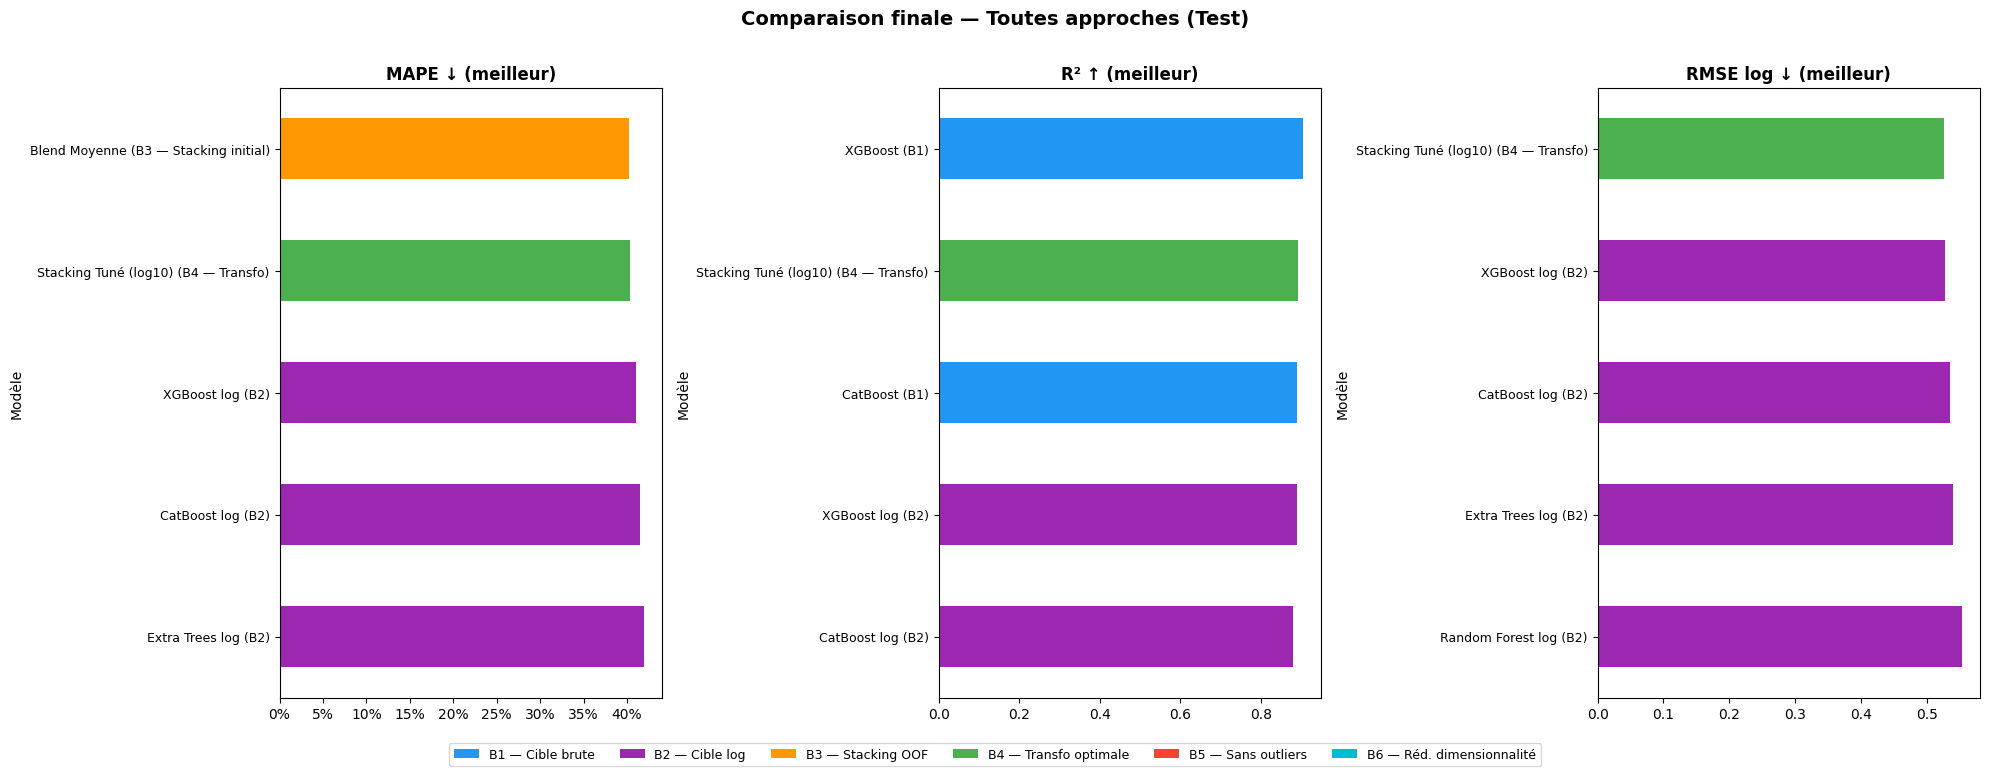

In [182]:
visualiser_comparaison_finale(df_all)

### C.3 : Modèle retenu et analyse par tranche

In [183]:
champion_lbl, preds_champion, champion_row = selectionner_modele_champion(df_recap_final)

Modèle retenu : XGBoost log (B2)
  MAPE     : 41.01%
  R²       : 0.8883
  MAE      :    3,232,319 €
  RMSE_log : 0.5283
